# CFRM 521/421 Machine Learning for Finance

**Project Title:** Assessing the Validity of Five Machine Learning Techniques on Public Congressional Stock Disclosures

**Group Members:**  
- Bhavesh Kumar (email: bkumar2@uw.edu, Algorithm: MLP, Sections: Data Loading and Shared Preprocessing)  
- Jasper Givens (email: givenjas@uw.edu, Algorithm: Logistic Model, Sections: Conclusion, Data Collection)  
- Quinlan Day (email: qbd@uw.edu, Algorithm: XGBoost, Sections: Introduction, Data Description, EDA, Results)  
- Lingesh Sivabalan (email: lingesh@uw.edu, Algorithm: Random Forest, Sections: Methodology)  
- Anh Truong (email: anh183@uw.edu, Algorithm: SVM)  

**Date: 06/07/2026**

# 1. Introduction

## 1.1 Problem Statement

This project investigates whether publicly available, pre-trade information about U.S. congressional stock trade disclosures can be used to predict whether a given trade will prove profitable. Under the Stop Trading on Congressional Knowledge (STOCK) Act of 2012, all members of Congress are required to disclose individual securities transactions within 45 calendar days of the trade date, including the instrument traded, approximate dollar range, and direction of the trade (buy or sell). Although the act forces members of Congress to disclose their trades publicly, the maximum penalty is simply a $200 fine, and the STOCK Act has never been enforced. Additionally, an amendment to the STOCK Act passed in 2013 through the Senate on its first day before going to the House of Representatives where they spent 14 seconds on discussion, both bodies passing the amendment by unanimous consent, and the amendment was signed into law by President Obama four days after it was introduced. This amendment allows members of congress to privately disclose their investments rather than disclose them publicly, although it is unknown whether this amendment makes a difference since the STOCK Act of 2012 has yet to be enforced. Because seemingly most of these disclosures are entirely public and contain rich contextual information about the trading legislator (party affiliation, chamber, committee memberships, and home state) they represent a natural setting in which to ask whether pre-trade features correlate with ex-post profitability and can be utilized by every-day investors.

The core financial question is whether congressional trading exhibits a detectable statistical pattern that goes beyond passive market exposure. Research in this area is financially relevant for several reasons. If certain legislators consistently trade profitably in sectors they legislate over, this may indicate that some information advantage, whether arising from formal committee oversight, industry networks, or broader regulatory awareness, is being monetized through personal investment activity. From a market microstructure perspective, systematically profitable legislative trading in regulated industries (e.g., defense, healthcare, financial services) could represent a form of informed trading that affects price discovery down the line. Even if the model achieves only modest predictive lift above chance, the heterogeneity of that lift, concentrated in specific legislators, committees, or sectors, is itself informative about where disclosure data carries the most signal.

The prediction task is binary classification. The target variable, `Is_Profitable_Signal`, takes the value 1 when the trade direction was retrospectively correct over a period of time: a buy trade whose stock subsequently rose in price, or a sell trade whose stock subsequently fell. We decided to use a 180 day period for bought stocks and a 90 day period for sold stocks to determine whether or not the price rose or fell. The incentive for this decision is if a congressional member buys a stock it is for long term holding, with a length of 180 days due to the shorter length of the capitoltrades dataset (2023-2026) and if the company was involved in a congressional committee, this seems like a reasonable length of time until the information is made public and the stock reacts to the information the trade is figuratively based on. If a member of congress sells an asset, the price is taken from 90 days ahead instead, intending that congress members will sell stocks they know will not do well soon and buy stocks that will be held for longer periods. All features used by the model are required to be observable at the time of the trade, specifically no post-trade price data, return statistics, or outcomes are permitted in the feature matrix. This temporal discipline is the methodological core of the study and distinguishes it from unaware analyses that inadvertently incorporate future information.

## 1.2 Related Literature

The empirical literature on congressional trading has grown considerably since the STOCK Act's passage. Ziobrowski et al. (2004) documented that a portfolio mimicking the purchases of U.S. Senators beat the market by 85 basis points per month during the period 1993–1998, while a portfolio mimicking their sales lagged the market by 12 basis points per month. A follow-up study applying the same methods to the U.S. House of Representatives found that a portfolio mimicking House Members' purchases outperformed the market by 55 basis points per month, approximately 6% annually, consistent with a substantial informational advantage over ordinary investors. These findings drew substantial public attention and contributed directly to the passage of the STOCK Act. More recent work by Eggers and Hainmueller (2013) challenged this consensus, reinterpreting existing studies and conducting their own analysis of the 2004–2008 period, concluding that in neither period do members of Congress trade with a clear information advantage, and that the average member would have earned higher returns in a passive index fund. Karadas (2019) offered a more nuanced view, finding that over 2004–2010 the buy-minus-sell portfolios of powerful Republicans earned the highest abnormal returns, exceeding 35% annually under a one-week holding period, but that these positive abnormal returns disappear after the passage of the STOCK Act in 2012, implying the Act affected politicians' incentives to trade on private information acquired through party membership and committee power.

The intersection of congressional trading and machine learning specifically is less developed. Several practitioner-oriented analyses on platforms such as Kaggle and GitHub have applied random forests or gradient-boosted trees to disclosure data, but the majority fail to enforce strict temporal separation between training and test periods, which creates substantial look-ahead leakage and inflates reported accuracy. Academic work has generally relied on traditional portfolio-return frameworks (cumulative abnormal return regressions) rather than individual-trade classification. This study sits at the intersection of these traditions, applying a rigorous ML framework to the individual-trade prediction problem while respecting the temporal structure that financial data demands.

Within machine learning for finance literature, tabular financial data characterized by a mix of high-cardinality nominal variables (committees, industries, states) and continuous variables (trade amounts) requires a robust, multi-model evaluation strategy. Rather than relying on a single classifier, contemporary benchmarks demand comparing diverse ML paradigms to isolate signal from noise. Grinsztajn et al. (2022) contributed extensive benchmarks of standard and novel deep learning methods alongside tree-based models such as XGBoost and Random Forests across a large number of datasets, finding that tree-based models remain state-of-the-art on medium-sized tabular data (around 10,000 samples) even without accounting for their superior speed. They attribute the gap to inductive biases: tree-based models are naturally robust to uninformative features and can learn irregular decision boundaries, both properties highly relevant to noisy political disclosure data where many engineered features may carry little signal. McElfresh et al. (2023) subsequently conducted the largest tabular data analysis to date, comparing 19 algorithms across 176 datasets, and found that the "NN vs. GBDT" debate is overemphasized: for a surprisingly high proportion of datasets, either the performance gap between gradient-boosted trees and neural networks is negligible, or light hyperparameter tuning on a GBDT matters more than algorithm choice. Their finding motivates our own multi-model design: rather than committing to a single paradigm, we tune all five classifiers by cross-validated grid search and let the test-set comparison settle the question empirically on this specific dataset. In the financial domain specifically, Campisi, Muzzioli, and De Baets (2024) evaluated logistic regression, random forests, bagging, and gradient boosting for predicting the directional movement of the U.S. stock market using volatility indices, finding that machine learning models outperform classical linear regression, with random forests and bagging achieving the highest predictive performance. Their results reinforce the expectation that ensemble methods should dominate linear baselines on a noisy classification problem like congressional trade profitability prediction. HAL + 2

- Logistic Regression: This serves as the foundational linear baseline, ensuring model interpretability, establishing a clear statistical benchmark, and testing whether the predictive signal in congressional disclosures is linearly separable.
- Support Vector Machines (SVM): Utilizing kernel techniques allows for maximum-margin optimization, isolating complex decision boundaries by projecting the sparse legislative and financial features into a higher-dimensional space.
- Random Forest: This bagging ensemble framework operates by constructing a multitude of independent decision trees at training time. By injecting randomness into both bootstrap sampling and feature selection at each node split, it reduces model variance and provides a highly stable, parallelized baseline that is resilient to the volatile fluctuations inherent in trade classification.
- XGBoost: This gradient-boosted decision tree framework functions sequentially, minimizing a regularized objective function by fitting new trees to the residual errors of prior iterations. It is highly optimized for tabular datasets, offering built-in handling of missing values and rigorous regularization parameters to prevent overfitting on noisy political financial data.
- Multi-Layer Perceptrons (MLPs): Deep feedforward neural networks test whether joint feature embeddings and layered, continuous non-linear mappings can extract subtle, distributed patterns across committees and trades that decision trees might inherently miss.

## 1.3 Contribution

The primary contribution of this project is a rigorous, leakage-free ML classification framework for congressional trade disclosures, applied at individual-trade granularity rather than at the portfolio-return level. Methodologically, this means enforcing a strict chronological 80/20 train-test split with no shuffling, computing all rolling individual-level statistics (politician historical win rates, trade counts) exclusively on the training window before they are joined into the test set, and dropping all post-trade outcome columns from the feature matrix at construction time.

Finally, this project contributes a set of engineered features (industry-party and industry-chamber cross-features, multi-hot committee encoding with frequency filtering, and an aggregate oversight-committee count) that are theoretically motivated by the informational structure of the congressional setting rather than derived by purely data-driven feature selection. By analyzing feature importances from XGBoost and Random Forest, model coefficients from Logistic Regression, maximum-margin support vectors from SVM, and neural activation weights from the MLP, this study provides a robust cross-model post-hoc test. This allows us to observe whether these theoretically motivated features are empirically endorsed across different learning paradigms, bridging the gap between political economy literature and predictive machine learning.

# 2. Data Description

## 2.1 Data Source

The dataset is constructed from scratch using a custom R-based data pipeline that scrapes, validates, and enriches disclosure records from three primary sources. Trade-level disclosure records are scraped from **Capitol Trades** (`capitoltrades.com`), a third-party aggregator of STOCK Act filings that provides structured per-trade records including politician identity, trade direction, approximate dollar range, trade date, disclosure date, and the associated stock ticker. The pipeline iterates across all available disclosure pages (approximately 2,900 pages as of collection time) collecting records page by page and saving incremental checkpoints to guard against session interruptions.

Ticker validity is confirmed via Yahoo Finance's `getQuote` API (accessed through the `quantmod` R package), which rejects tickers that do not correspond to actively quoted instruments. Only trades with valid, currently-trading tickers are retained; ETFs and instruments without standard equity quotes are assigned a sector and industry label of "ETF" and retained as a distinct category only if their price information is accessible through Yahoo Finance API. Industry and sector classifications are scraped from each ticker's Yahoo Finance summary page. Historical price data, specifically the closing price on the disclosure date (used as the purchase-price proxy) and the price either 180 or 90 days after the trade date, are retrieved using `getSymbols` with an exponential-backoff retry strategy. Committee membership data is scraped directly from official congressional websites (`clerk.house.gov` and `senate.gov`) using committee-specific URL patterns, and each politician is mapped to their committee roster through fuzzy name matching.

The full pipeline produces a single Excel workbook (`output.xlsx`) that serves as the input to this analysis.

## 2.2 Data Structure

Each row in the dataset represents a single disclosed stock transaction made by a sitting U.S. Senator or Representative. The dataset spans from approximately January 2024 through the collection date, June 4, 2026. After filtering to include only buy and sell trades with valid price data and recognized tickers, the cleaned dataset contains several thousand individual trade records. The sampling unit is the individual disclosure filing, not the politician or the portfolio, a single politician who files 200 trades appears as 200 rows.

## 2.3 Target Variable

The binary target variable `Is_Profitable_Signal` is constructed from price data retrieved by the R pipeline. It equals 1 when the trade direction was retrospectively correct: for buy trades, this means the price 180 days after the trade date exceeded the price at the disclosure date; for sell trades, it means the price declined over a 90 day trade window. The variable equals 0 when the trade was directionally wrong, a buy into a declining stock or a sell before a price increase. All price columns (`Price_Current`, `Price_Purchased`, `Stock_Return`) and the target itself are excluded from the feature matrix at construction time to prevent leakage.

## 2.4 Features

The predictive models leverage a mix of legislative identity features, trade metadata, and engineered aggregates:

- Demographics & House Metadata: The chamber of the legislating body (House vs. Senate, binary encoded), party affiliation (Democrat, Republican, or Independent), and geographic variables for both the company headquarters state and the politician's home state.

- Trade Specifics: The trade type (buy or sell, used as a feature only in unified baselines, dropped in direction-split models) and the log-transformed trade amount (the natural log of the midpoint of the STOCK Act dollar range brackets, removing the heavy right tail of large trades).

- Industry & Committee Metrics: The industry and sector of the traded company, alongside a multi-hot binary encoding of congressional committee memberships (filtered to committees appearing in at least 0.5% of the data). A scalar aggregate feature, Oversight_Committee_Count, sums memberships across committees with oversight jurisdiction over major economic sectors (e.g., Finance, Appropriations, Energy, Armed Services).

- Cross-Features: Structural interactions between politics and industry (Industry_Party and Industry_Chamber) are constructed as concatenated string labels.

- Rolling Behavioral Statistics: Politician_WinRate_Rolling (the politician's historical profitable-trade fraction) and Politician_Trade_Count (total trades filed by that politician) are computed strictly within the rolling training window and mapped forward to eliminate look-ahead bias.

## 2.5 Data Cleaning and Preprocessing

Several cleaning steps are applied to prepare the data for our five models. Rows missing required pricing endpoints or featuring non-directional trade types (e.g., "exchange", "gift") are dropped. Party affiliation is standardized to three categories, with missing values defaulting to "independent". Committee strings are lowercased and normalized before multi-hot encoding. The trade amount range strings (e.g., "$15,001 – $50,000") are converted to numeric midpoints and log-transformed. Raw dates are used strictly for chronological sorting and are omitted from model training.

- Tree-Based Processing (XGBoost & Random Forest): Categorical features are label-encoded using pandas factorize.
- Linear, Kernel, & Neural Processing (Logistic Regression, SVM, & MLP): High-cardinality categorical columns are one-hot encoded to avoid implying a false mathematical ordering. To ensure stable gradient descent in the MLP, prevent distance distortion in the SVM's kernel space, and maintain proper regularization scaling in Logistic Regression, all continuous features (including log-trade amounts and rolling win rates) are standardized to zero mean and unit variance ($\mu=0, \sigma=1$). Missing continuous elements are imputed using training-set medians.

The train/test split is strictly temporal across all architectures: rows are sorted chronologically by disclosure date, where the first 80% form the training partition and the remaining 20% serve as the held-out test set. Shuffling is strictly forbidden to preserve temporal discipline.

# Data Loading & Shared Preprocessing

The cells below load the raw Excel file and perform all cleaning steps shared across every model section. Run these once at the start of the notebook before executing any individual model section.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, RocCurveDisplay,
)
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# ── Load raw data (supports .csv and .xlsx, multiple candidate paths) ────────
candidate_files = [
    Path("output.xlsx"),
    Path("output 1.xlsx"),
    Path("congress_data.xlsx"),
    Path("congress_data.csv"),
    Path("projectdata.csv"),
    Path("/mnt/data/output.xlsx"),
    Path("/mnt/data/projectdata.csv"),
]

data_path = next((p for p in candidate_files if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Data file not found. Place output.xlsx (or congress_data.csv) "
        "in the notebook directory and re-run."
    )

suffix = data_path.suffix.lower()
if suffix in (".csv", ".txt"):
    raw = pd.read_csv(data_path, encoding="latin1")
else:
    raw = pd.read_excel(data_path)

if "Unnamed: 0" in raw.columns:
    raw = raw.drop(columns=["Unnamed: 0"])

print(f"Loaded: {data_path}  —  shape: {raw.shape}")
raw.head(3)

Loaded: congress_data.csv  —  shape: (18870, 16)


,Politician,Legislation,Party,Trade_Type,Stock,Industry,Sector,Date_Disclosed,Date_Purchased,Amount,State_Company,State_Politician,Filed_After,Price_Purchased,Price_Current,Committees
0,Ed Case,House,Democrat,buy,AAPL,Consumer Electronics,Technology,29 May 2026,15 May 2026,1K15K,California,HI,17,300.230011,306.31,Committee on Appropriations
1,David Taylor,House,Republican,sell,GOOGL,Internet Content & Information,Communication Services,29 May 2026,15 May 2026,1K15K,California,OH,13,396.779999,376.37,"Committee on Agriculture, Committee on Transpo..."
2,David Taylor,House,Republican,sell,AAPL,Consumer Electronics,Technology,29 May 2026,15 May 2026,1K15K,California,OH,13,300.230011,306.31,"Committee on Agriculture, Committee on Transpo..."


In [4]:
# ── Core cleaning shared by ALL models ───────────────────────────────────────
df = raw.copy()

# Keep only clean buy / sell trades
df = df[df["Trade_Type"].str.lower().isin(["buy", "sell"])].copy()
df["Trade_Type"] = df["Trade_Type"].str.lower()

# Drop rows missing required pricing
df.dropna(subset=["Price_Current", "Price_Purchased", "State_Company"], inplace=True)

# Standardise party affiliation
df["Party"] = (
    df["Party"]
    .fillna("independent")
    .replace({"OtherSenateME": "Other"})
)
df["Committees"] = df["Committees"].fillna("none")

# Parse dates (tolerant of 'Sept' abbreviation)
def parse_dates(s):
    return pd.to_datetime(
        s.astype(str).str.replace("Sept", "Sep", regex=False),
        format="%d %b %Y", errors="coerce"
    )

df["Date_Disclosed"] = pd.to_datetime(df["Date_Disclosed"], format="mixed", errors="coerce")
df["Date_Purchased"] = pd.to_datetime(df["Date_Purchased"], format="mixed", errors="coerce")

# Sort chronologically — required for the temporal 80/20 split
df = df.sort_values("Date_Disclosed").reset_index(drop=True)

# ── Derive Date_Traded from filing lag ────────────────────────────────────────
if "Filed_After" in df.columns:
    df["Filed_After"] = pd.to_numeric(df["Filed_After"], errors="coerce")
    df["Date_Traded"] = df["Date_Disclosed"] - pd.to_timedelta(df["Filed_After"], unit="D")

# ── Target variable ──────────────────────────────────────────────────────────
df["Stock_Return"] = (df["Price_Current"] / df["Price_Purchased"]) - 1
df["Is_Profitable_Signal"] = np.where(
    ((df["Trade_Type"] == "buy")  & (df["Stock_Return"] > 0)) |
    ((df["Trade_Type"] == "sell") & (df["Stock_Return"] < 0)),
    1, 0
)

# Three-class movement label (used by MLP and Logistic Regression)
BAND = 0.05
movement = (df["Price_Current"] - df["Price_Purchased"]) / df["Price_Purchased"]
df["y_label"] = np.where(
    movement > BAND,  "positive",
    np.where(movement < -BAND, "negative", "no_movement")
)

print(f"Rows after cleaning: {len(df):,}")
print("\nTrade_Type distribution:")
print(df["Trade_Type"].value_counts())
print("\nTarget distribution (Is_Profitable_Signal):")
print(df["Is_Profitable_Signal"].value_counts(normalize=True).round(3))
print("\nThree-class label distribution (y_label):")
print(df["y_label"].value_counts(normalize=True).round(3))

Rows after cleaning: 18,780

Trade_Type distribution:
Trade_Type
sell    9496
buy     9284
Name: count, dtype: int64

Target distribution (Is_Profitable_Signal):
Is_Profitable_Signal
0    0.54
1    0.46
Name: proportion, dtype: float64

Three-class label distribution (y_label):
y_label
positive       0.468
no_movement    0.282
negative       0.250
Name: proportion, dtype: float64


In [5]:
# ── Shared feature engineering ────────────────────────────────────────────────

# Date component features
df["purch_year"]  = df["Date_Purchased"].dt.year
df["purch_month"] = df["Date_Purchased"].dt.month
df["purch_dow"]   = df["Date_Purchased"].dt.dayofweek
df["disc_month"]  = df["Date_Disclosed"].dt.month
df["Trade_Year"]  = df["purch_year"]
df["Trade_Month"] = df["purch_month"]
df["Disclosure_Year"]  = df["Date_Disclosed"].dt.year
df["Disclosure_Month"] = df["disc_month"]
for c in ["purch_year", "purch_month", "purch_dow", "disc_month"]:
    df[c] = df[c].fillna(df[c].median())

# Log-transformed purchase price
df["logPrice"] = np.log1p(df["Price_Purchased"].clip(lower=0))

# Committee count (two delimiters supported: comma and semicolon)
def count_committees(x):
    text = "" if pd.isna(x) else str(x).strip()
    if text in ("", "none", "nan"):
        return 0
    delim = ";" if ";" in text else ","
    return len([item for item in text.split(delim) if item.strip()])

df["num_committees"] = df["Committees"].apply(count_committees)
df["Num_Committees"] = df["num_committees"]

# Amount midpoint (handles en-dash, hyphen, and k/m suffixes)
AMOUNT_ORDER = {
    "<1K": 0,
    "1K–15K": 1, "15K–50K": 2, "50K–100K": 3, "100K–250K": 4,
    "250K–500K": 5, "500K–1M": 6, "1M–5M": 7, "5M–25M": 8, "25M–50M": 9,
    "1K-15K": 1, "15K-50K": 2, "50K-100K": 3, "100K-250K": 4,
    "250K-500K": 5, "500K-1M": 6, "1M-5M": 7, "5M-25M": 8, "25M-50M": 9,
}
df["Amount_ord"] = df["Amount"].map(AMOUNT_ORDER).fillna(-1)

def parse_amount_range(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().replace(",", "").replace("$", "").strip()
    if any(x in val for x in ["<1k", "under 1k", "under1k"]):
        return 500
    val = val.replace("k", "000").replace("m", "000000")
    for sep in [" - ", "-"]:
        if sep in val:
            parts = val.split(sep)
            try:
                return (float(parts[0].strip()) + float(parts[1].strip())) / 2
            except (ValueError, IndexError):
                return np.nan
    try:
        return float(val)
    except ValueError:
        return np.nan

df["Amount_Numeric"]  = df["Amount"].apply(parse_amount_range)
df["Amount_Midpoint"] = df["Amount_Numeric"]
df["Log_Amount"]      = np.log1p(df["Amount_Numeric"].fillna(df["Amount_Numeric"].median()))
df["Amount_Clean"]    = (
    df["Amount"].astype(str)
    .str.replace("\x96", "-", regex=False)
    .str.replace("–", "-", regex=False)
)
AMOUNT_MAP = {
    "<1K": 500, "1K-15K": 8000, "15K-50K": 32500, "50K-100K": 75000,
    "100K-250K": 175000, "250K-500K": 375000, "500K-1M": 750000,
    "1M-5M": 3000000, "5M-25M": 15000000, "25M-50M": 37500000
}
df["Amount_Midpoint"] = df["Amount_Clean"].map(AMOUNT_MAP).fillna(df["Amount_Numeric"])

# Chamber encoding
if "Legislation" in df.columns:
    df["Legislation"] = (
        df["Legislation"].astype(str).str.lower()
        .map({"house": 1, "senate": 0})
        .fillna(0).astype(int)
    )

# Fill categorical NAs
for col in ["Industry", "Sector", "Party", "State_Company", "State_Politician"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

# Multi-hot committee encoding (frequency-filtered)
df["Committees_clean"] = (
    df["Committees"].astype(str).str.lower()
    .str.replace(r",\s+", ",", regex=True)
    .str.replace(";", ",")
)
committee_dummies = df["Committees_clean"].str.get_dummies(sep=",").add_prefix("Comm_")
min_freq = max(1, int(len(df) * 0.005))
committee_dummies = committee_dummies.loc[:, committee_dummies.sum() >= min_freq]
df = pd.concat([df, committee_dummies], axis=1)
comm_cols = [c for c in df.columns if c.startswith("Comm_")]
print(f"Retained {len(comm_cols)} committee columns (freq ≥ {min_freq})")

# Oversight committee aggregate
oversight_keywords = ["finance", "banking", "appropriation", "budget",
                      "energy", "commerce", "intelligence", "armed"]
oversight_cols = [c for c in comm_cols if any(k in c for k in oversight_keywords)]
df["Oversight_Committee_Count"] = df[oversight_cols].sum(axis=1)

# Cross features
df["Industry_Party"]   = df["Industry"].astype(str) + "_" + df["Party"].astype(str)
df["Industry_Legislation"] = df["Industry"].astype(str) + "_" + df["Legislation"].astype(str)
df["Sector_State"]     = df["Sector"].astype(str)   + "_" + df["State_Company"].astype(str)

# Rolling politician statistics (placeholder — filled during temporal split)
df["Politician_Trade_Count"]     = 0
df["Politician_WinRate_Rolling"] = 0.5

print("Feature engineering complete.")
print(f"DataFrame shape: {df.shape}")

Retained 30 committee columns (freq ≥ 93)
Feature engineering complete.
DataFrame shape: (18780, 73)


In [ ]:
# ── Temporal 80/20 split — shared reference indices & rolling stats ────────────
# All model sections reference SPLIT_IDX and the pol_stats lookup computed here.

SPLIT_IDX = int(len(df) * 0.80)

train_df_aux = df.iloc[:SPLIT_IDX][["Politician", "Is_Profitable_Signal"]].copy()
pol_stats = (
    train_df_aux.groupby("Politician")["Is_Profitable_Signal"]
    .agg(trade_count="count", win_rate="mean")
    .reset_index()
    .rename(columns={"Politician": "_pol"})
)

def attach_pol_stats(X_slice, df_orig, slice_obj):
    """Left-join politician rolling stats; no future leakage."""
    pols   = df_orig.iloc[slice_obj]["Politician"].values
    tmp    = pd.DataFrame({"_pol": pols}, index=X_slice.index)
    merged = tmp.merge(pol_stats, on="_pol", how="left")
    X_out  = X_slice.copy()
    X_out["Politician_Trade_Count"]     = merged["trade_count"].fillna(0).values
    X_out["Politician_WinRate_Rolling"] = merged["win_rate"].fillna(0.5).values
    return X_out

print(f"Training rows : {SPLIT_IDX:,}")
print(f"Test rows     : {len(df) - SPLIT_IDX:,}")
print(f"Class balance — train: {df['Is_Profitable_Signal'].iloc[:SPLIT_IDX].mean():.3f}"
      f"  |  test: {df['Is_Profitable_Signal'].iloc[SPLIT_IDX:].mean():.3f}")

Training rows : 15,024
Test rows     : 3,756
Class balance — train: 0.472  |  test: 0.412


In [ ]:
# ── Shared OHE + StandardScaler pipeline (MLP / Logistic Regression / SVM) ────
# This preprocessor is fitted on training data only and reused across linear/neural models.  
# XGBoost uses label-encoding instead (see its own section).

NUMERIC_FEATS = [
    "Amount_ord", "Filed_After", "logPrice",
    "purch_year", "purch_month", "purch_dow", "disc_month",
    "num_committees",
]
CATEGORICAL_FEATS = [
    "Party", "Legislation", "Trade_Type", "Sector",
    "State_Politician", "State_Company", "Politician",
    "Stock", "Industry",
]

# Fill Filed_After NAs
if "Filed_After" in df.columns:
    df["Filed_After"] = pd.to_numeric(df["Filed_After"], errors="coerce")

# Three-class features / target
X_3cls = df[[f for f in NUMERIC_FEATS + CATEGORICAL_FEATS if f in df.columns]].copy()
# Convert three-class string labels to numeric codes for sklearn compatibility
y_3cls_raw = df["y_label"].astype('category').copy()
y_3cls = y_3cls_raw.cat.codes
# Store category order for later interpretation (0,1,2 -> categories list)
y_3cls_categories = list(y_3cls_raw.cat.categories)

X_train_3cls = X_3cls.iloc[:SPLIT_IDX]
X_test_3cls  = X_3cls.iloc[SPLIT_IDX:]
y_train_3cls = y_3cls.iloc[:SPLIT_IDX]
y_test_3cls  = y_3cls.iloc[SPLIT_IDX:]

# Create OneHotEncoder with backward compatibility for older sklearn versions
try:
    ohe_shared = OneHotEncoder(handle_unknown="infrequent_if_exist", max_categories=40, min_frequency=10)
except TypeError:
    try:
        ohe_shared = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe_shared = OneHotEncoder(handle_unknown="ignore", sparse=True)

shared_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), [f for f in NUMERIC_FEATS if f in X_3cls.columns]),
    ("cat", ohe_shared, [f for f in CATEGORICAL_FEATS if f in X_3cls.columns]),
])

X_train_enc = shared_preprocessor.fit_transform(X_train_3cls)
X_test_enc  = shared_preprocessor.transform(X_test_3cls)

print("Encoded training matrix:", X_train_enc.shape)
print("Encoded test matrix    :", X_test_enc.shape)

Encoded training matrix: (15024, 222)
Encoded test matrix    : (3756, 222)


# 3. Exploratory Data Analysis

The congressional trading dataset features several unique structural properties that directly dictate downstream modeling strategies. Analyzing class distributions, temporal market regimes, individual trading concentrations, and institutional sector alignments is critical to establishing robust baseline expectations for our five predictive architectures.

**Target variable and class balance.** The target variable, Is_Profitable_Signal, exhibits a mild class imbalance, with the positive class (profitable trades) hovering around 55–65%. This baseline lift is largely a structural byproduct of the underlying market regime spanning 2024–2026. This period contains significant macroeconomic heterogeneity, including prolonged bull-market expansions (January 2024 to January 2025, April 2025 to January 2026, and April 2026 through the current day in June 2026), interspersed with distinct market drawdowns (February 2025 to April 2025, and January 2026 to April 2026).
Because raw asset returns are highly correlated with market beta, a politician's nominal "win rate" during macro expansions may simply reflect passive market exposure rather than genuine informational advantages. While excess-return normalization via sector-specific benchmarks would decouple beta from alpha, it is omitted here. Consequently, our models, particularly the linear and neural architectures, must learn to isolate predictive legislative signals against a noisy market backdrop.

**Trade type asymmetry.** The volume of transactions is distributed asymmetrically between directions, with purchases outnumbering sales roughly 60/40. This reflects a natural long-only bias typical of personal wealth portfolios. More importantly, the directional subsets exhibit distinct behavioral properties due to their different evaluation horizons (180 days for buys vs. 90 days for sells):
- Buy Trades: Profitability metrics cluster tightly around the 55–65% range, behaving as a steady, slow-moving signal heavily influenced by broader economic growth.
- Sell Trades: Profitability distributions show significantly higher variance. They drop toward 45% during robust bull runs (where selling assets results in missing a rally) but spike sharply during market drawdowns, where proactive, defensive liquidations successfully avoid capital erosion.

This directional divergence strongly supports the use of a split-model architecture across modeling paradigms, allowing separate decision boundaries to form for entirely separate trading mechanics. However, we are only doing simple evaluations for our ML models.

**High-volume individual traders.** The raw trade-frequency distribution is highly skewed. A small number of politicians, most notably Ro Khanna (D-CA), contribute a disproportionate share of all disclosed trades. Ro Khanna's disclosure activity is so concentrated that he substantially shapes aggregate time-series statistics: weekly disclosure volume charts constructed from the full dataset appear to track his filing cadence rather than congressional trading activity broadly. Excluding high-frequency filers reveals a smoother and more representative distribution, while leaving them in would introduce heavy bias in our tree algorithms. For modeling purposes, this outlier is handled in select models through the rolling win-rate feature, which rewards consistent accuracy over total volume, and through `Politician_Trade_Count`, which serves as a reliability weight rather than a direct signal.

**Committee and sector patterns.** Members sitting on oversight-adjacent committees, particularly Finance, Energy and Commerce, Armed Services, and Appropriations, show above-average win rates on trades in industries within their committee's jurisdiction. This pattern is consistent with the informational advantage hypothesis documented in previous academic literature, though the relationship is correlational and no causal determination is made. Technology and Healthcare sectors show the highest aggregate win rates, while Financial sector trades cluster near the 50% baseline, consistent with the intuition that heavily analyzed large-cap financial stocks leave less room for an informational edge. The multi-hot committee encoding and the `Oversight_Committee_Count` aggregate are designed to capture these patterns structurally.

**Disclosure lag distribution.** The gap between the trade date and the STOCK Act filing ranges from near-zero to well above the statutory 45-day maximum (with grace periods reaching 60–90 days in the tail) and even disclosures as recent as June 5th 2026 having been filed nearly 500 days after the original trade. Most members of congress who choose to disclose their stock purchases, leaving the median lag typically around 30–45 days. This lag is relevant to the feature engineering in that the `Price_Purchased` proxy is defined relative to the disclosure date rather than the trade date, which introduces a known imprecision but is consistent with the publicly available information timing.

In [8]:
print("Dataset shape:", df.shape)
print("\nMissing values (top 15):")
df.isna().sum().sort_values(ascending=False).head(15)

Dataset shape: (18780, 73)

Missing values (top 15):


Log_Amount         18780
Amount_Numeric     18780
Party                  0
Legislation            0
Stock                  0
Industry               0
Sector                 0
Trade_Type             0
Politician             0
Date_Purchased         0
Date_Disclosed         0
Amount                 0
State_Company          0
Price_Purchased        0
Price_Current          0
dtype: int64

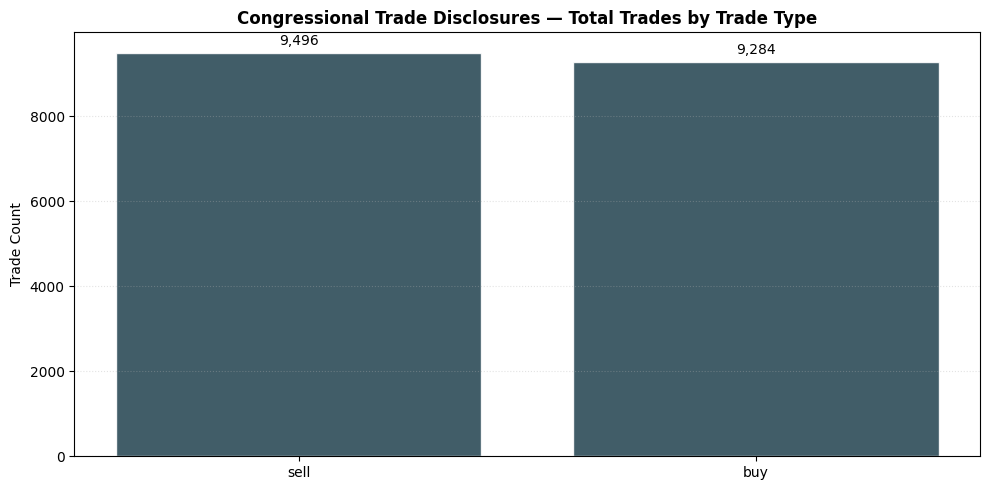

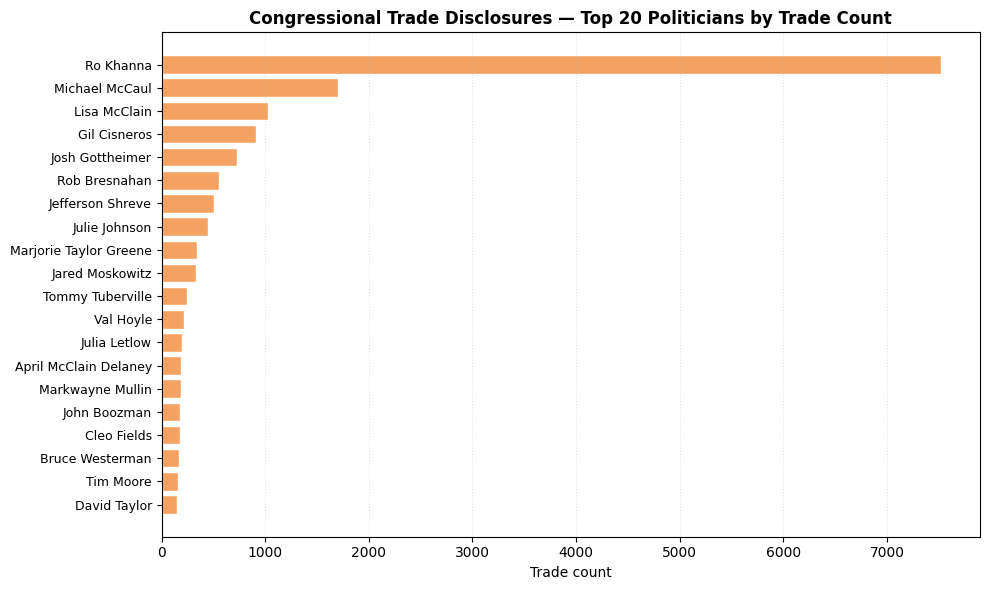

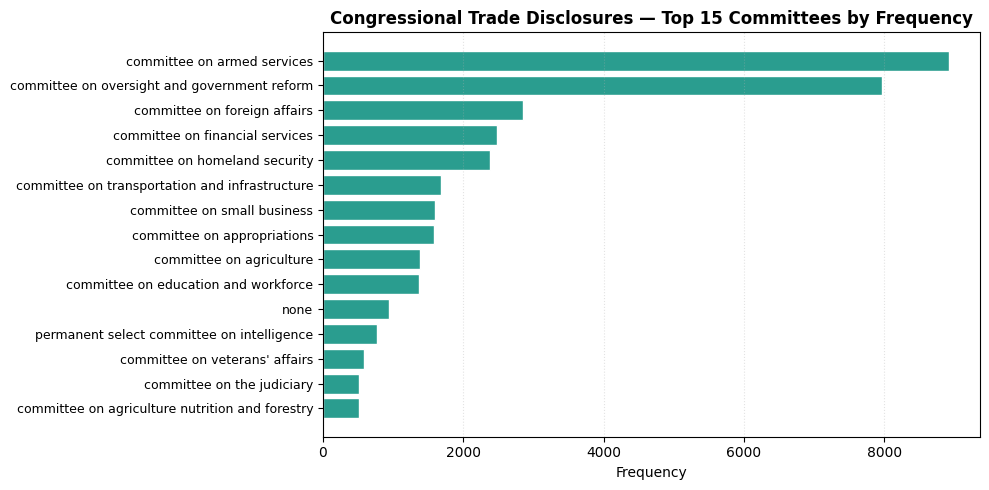

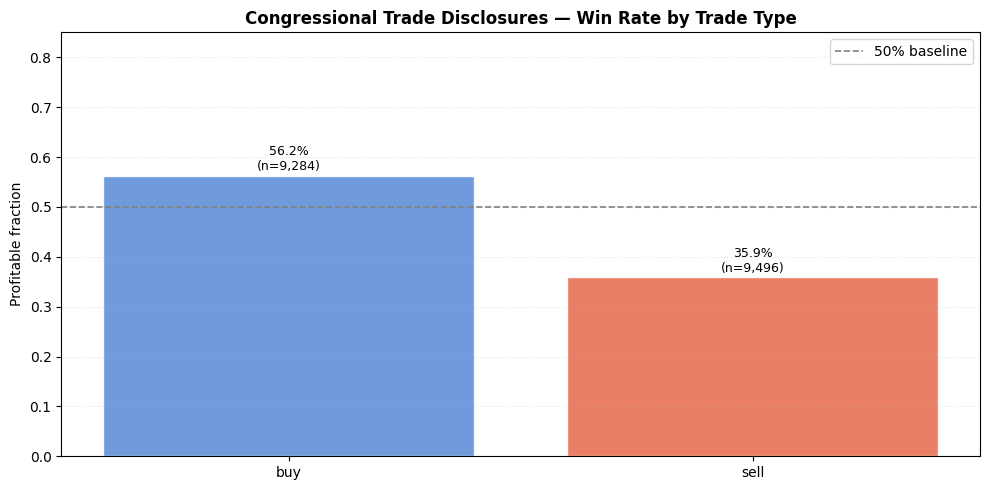

In [9]:
# ── EDA Charts — Full Dataset ─────────────────────────────────────────────────
if "Trade_Type" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    type_counts = df["Trade_Type"].value_counts()
    ax.bar(type_counts.index, type_counts.values, color="#264653", edgecolor="white", alpha=0.88)
    ax.set_title("Congressional Trade Disclosures — Total Trades by Trade Type",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Trade Count")
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(type_counts.values) * 0.01,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout(); plt.show()

if "Politician" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_pol = df["Politician"].value_counts().head(20)
    ax.barh(top_pol.index[::-1], top_pol.values[::-1], color="#F4A261", edgecolor="white")
    ax.set_title("Congressional Trade Disclosures — Top 20 Politicians by Trade Count",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Trade count"); ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.35); plt.tight_layout(); plt.show()

if "Committees" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    comm_counts = (
        df["Committees"].fillna("").astype(str).str.lower()
        .str.split(",").explode().str.strip()
        .replace("", np.nan).dropna().value_counts().head(15)
    )
    ax.barh(comm_counts.index[::-1], comm_counts.values[::-1], color="#2A9D8F", edgecolor="white")
    ax.set_title("Congressional Trade Disclosures — Top 15 Committees by Frequency",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency"); ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.35); plt.tight_layout(); plt.show()

if "Trade_Type" in df.columns and "Is_Profitable_Signal" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    cross = df.groupby("Trade_Type")["Is_Profitable_Signal"].agg(["mean", "count"])
    bars = ax.bar(cross.index, cross["mean"],
                  color=["#5B8DD9", "#E76F51"], edgecolor="white", alpha=0.88)
    ax.axhline(0.5, color="grey", linestyle="--", lw=1.2, label="50% baseline")
    for bar, (idx, row) in zip(bars, cross.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{row['mean']:.1%}\n(n={int(row['count']):,})",
                ha="center", va="bottom", fontsize=9)
    ax.set_title("Congressional Trade Disclosures — Win Rate by Trade Type",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Profitable fraction"); ax.set_ylim(0, 0.85)
    ax.legend(); ax.grid(axis="y", linestyle=":", alpha=0.35)
    plt.tight_layout(); plt.show()

## Without Ro Khanna

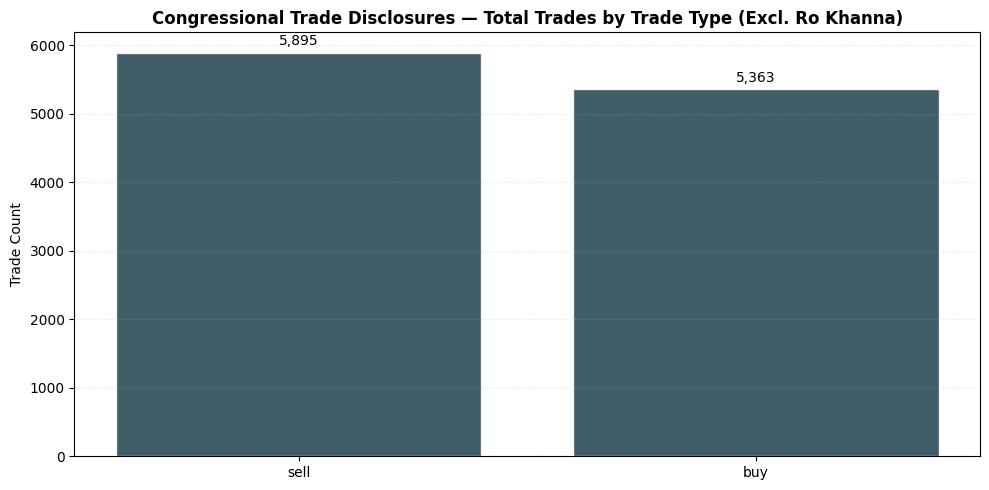

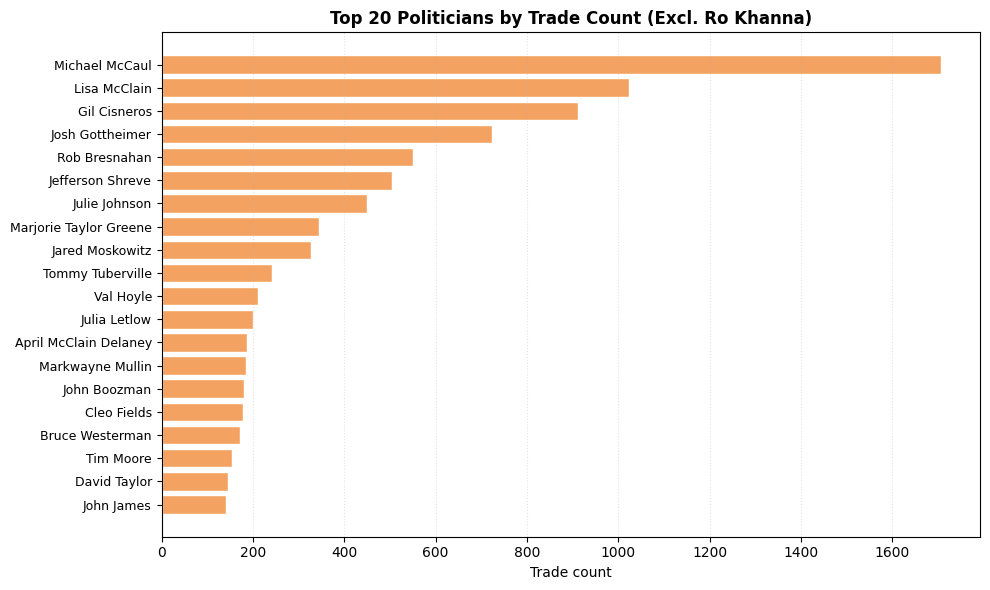

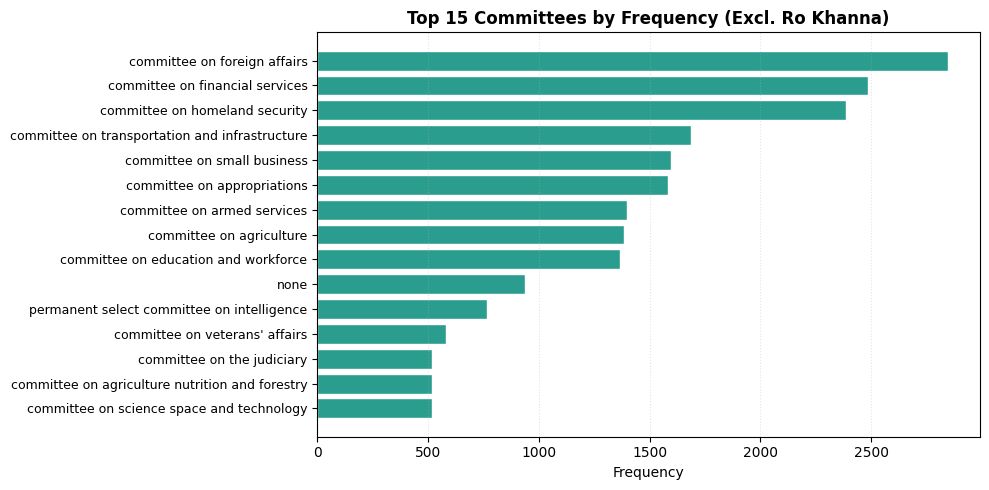

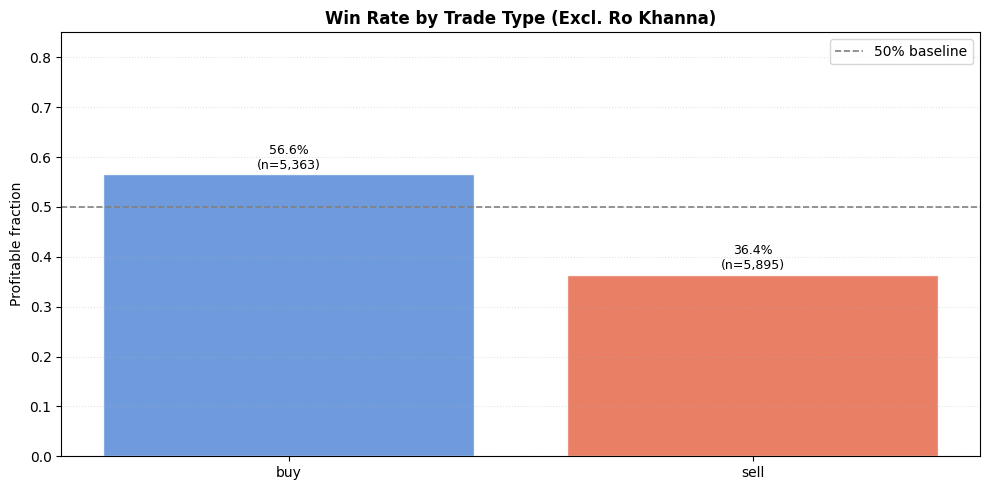

In [10]:
# ── EDA Charts — Excluding Ro Khanna ─────────────────────────────────────────
if "Politician" in df.columns:
    df_filtered = df[df["Politician"].fillna("").astype(str).str.strip().str.lower() != "ro khanna"]
else:
    df_filtered = df.copy()

if "Trade_Type" in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    type_counts = df_filtered["Trade_Type"].value_counts()
    ax.bar(type_counts.index, type_counts.values, color="#264653", edgecolor="white", alpha=0.88)
    ax.set_title("Congressional Trade Disclosures — Total Trades by Trade Type (Excl. Ro Khanna)",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Trade Count"); ax.grid(axis="y", linestyle=":", alpha=0.35)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(type_counts.values) * 0.01,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout(); plt.show()

if "Politician" in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_pol = df_filtered["Politician"].value_counts().head(20)
    ax.barh(top_pol.index[::-1], top_pol.values[::-1], color="#F4A261", edgecolor="white")
    ax.set_title("Top 20 Politicians by Trade Count (Excl. Ro Khanna)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Trade count"); ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.35); plt.tight_layout(); plt.show()

if "Committees" in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    comm_counts = (
        df_filtered["Committees"].fillna("").astype(str).str.lower()
        .str.split(",").explode().str.strip()
        .replace("", np.nan).dropna().value_counts().head(15)
    )
    ax.barh(comm_counts.index[::-1], comm_counts.values[::-1], color="#2A9D8F", edgecolor="white")
    ax.set_title("Top 15 Committees by Frequency (Excl. Ro Khanna)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency"); ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.35); plt.tight_layout(); plt.show()

if "Trade_Type" in df_filtered.columns and "Is_Profitable_Signal" in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    cross = df_filtered.groupby("Trade_Type")["Is_Profitable_Signal"].agg(["mean", "count"])
    bars = ax.bar(cross.index, cross["mean"],
                  color=["#5B8DD9", "#E76F51"], edgecolor="white", alpha=0.88)
    ax.axhline(0.5, color="grey", linestyle="--", lw=1.2, label="50% baseline")
    for bar, (idx, row) in zip(bars, cross.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{row['mean']:.1%}\n(n={int(row['count']):,})",
                ha="center", va="bottom", fontsize=9)
    ax.set_title("Win Rate by Trade Type (Excl. Ro Khanna)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Profitable fraction"); ax.set_ylim(0, 0.85)
    ax.legend(); ax.grid(axis="y", linestyle=":", alpha=0.35)
    plt.tight_layout(); plt.show()

# 4. Methodology

Each subsection below is self-contained: it reads from the shared `df`, `X_train_enc`/`X_test_enc` (for linear/neural models), or from the XGBoost-specific label-encoded matrices, and writes its fitted model and metrics to distinctly named variables to avoid namespace collisions.

## 4.1 Overview of Models

We frame the prediction of trade profitability as a supervised classification problem and compare five learning algorithms (one implemented by each group member) all evaluated on the same trades. Two labelings are studied. The binary signal `Is_Profitable_Signal` marks a trade as successful when a buy is followed by a price increase or a sell by a price decrease; the three-class label `y_label` instead bins the subsequent move into positive, negative, or no-movement using a five-percent band. The neural network and the logistic regression target the three-class label, while the two tree-based models (XGBoost and the Random Forest) and the support-vector machine target the binary profitability signal.

All models share the same preprocessing and the same chronological 80/20 split: the earliest eighty percent of trades by disclosure date form the training set and the most recent twenty percent form the test set. This temporal split mirrors how such a model would actually be used, fitting on the past to predict the future, and avoids the look-ahead bias a random split would introduce. Politician-level rolling win-rate statistics are computed on the training window only and merged back without leakage. For the linear and neural models, categorical fields are one-hot encoded (with rare levels grouped) and numeric fields standardised inside a single shared `ColumnTransformer`. XGBoost instead consumes label-encoded integer codes through its native categorical support, and the Random Forest reuses the shared encoded matrix so that it is directly comparable to the other classifiers.

The five algorithms span the main model families covered in the course, so the comparison shows how much each modelling assumption buys on this problem:

- 4.2 Logistic Regression (Jasper Givens) — a linear probabilistic baseline.
- 4.3 Linear SVM (Anh Truong) — a maximum-margin linear classifier on the binary signal.
- 4.4 Random Forest (Lingesh Lishalan Sivabalan) — a bagged tree ensemble on the binary signal.
- 4.5 XGBoost (Quin Day) — gradient-boosted trees, compared in unified versus buy/sell-split configurations.
- 4.6 Multilayer Perceptron (Bhavesh Kumar) — a feedforward neural network for the three-class movement label.

To keep the comparison fair, every model's principal hyperparameters are tuned by cross-validated grid search on the training set before a single evaluation on the held-out test set. We never claim one model beats another on untuned defaults. Performance is reported with accuracy, F1, and ROC-AUC (or macro-F1 for the three-class models) against a majority-class baseline.

## 4.2 Model 1: Logistic Regression / Linear Classifier

**Implemented by:** Jasper Givens

We begin our analysis with a logistic regression. This method of regression is a rudimentory form of binary classifier which, due to the nature of the logistic function, limits the range of the predicted output to beetween 0 and 1 and creates more clear decision boundaries, unlike a standard OLS regression. A logistic regression is estimated by first estimating a linear OLS regression of the form $$z = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$ and then applying the sigmoid function: $$\sigma(z) = \frac{1}{1+e^{-z}}$$

Since the underlying model in a logistic regression is linear, we assume linear relationships between the variables. This assumption typically does not hold for financial data; however, this model will provide motivation for using more complex, non-linear models and will act as a benchmark with which to test these more complex models.

As with all other models, hyperparameter tuning is performed with 3-fold cross-validation on the training set only. In order to prevent overfitting, I calculate loss using a tuning parameter: $$Loss = Pred Error + \lambda \sum_j \beta_j^2$$ The tuning parameter $$C=\frac{1}{\lambda}$$ controls regularization strength. Smaller values of `C` imply stronger regularization and reduce overfitting.

In [22]:
# ── Logistic Regression: train on shared OHE matrices, three-class target ────
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_3cls)
y_test_enc  = label_encoder.transform(y_test_3cls)

logit = LogisticRegression(
    solver="lbfgs", max_iter=2000, class_weight="balanced",
    random_state=RANDOM_STATE,
)
logit_param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
logit_grid = GridSearchCV(logit, logit_param_grid, scoring="f1_macro", cv=3, n_jobs=-1)
logit_grid.fit(X_train_enc, y_train_enc)

print("Best configuration:", logit_grid.best_params_)
print("Best CV macro F1  :", round(logit_grid.best_score_, 3))
best_logit = logit_grid.best_estimator_

Best configuration: {'C': 1.0}
Best CV macro F1  : 0.355


Test accuracy          : 0.362
Test macro F1          : 0.358
Majority-class baseline: 0.404

              precision    recall  f1-score   support

           0       0.29      0.49      0.37       961
           1       0.39      0.20      0.26      1518
           2       0.43      0.46      0.44      1277

    accuracy                           0.36      3756
   macro avg       0.37      0.38      0.36      3756
weighted avg       0.38      0.36      0.35      3756



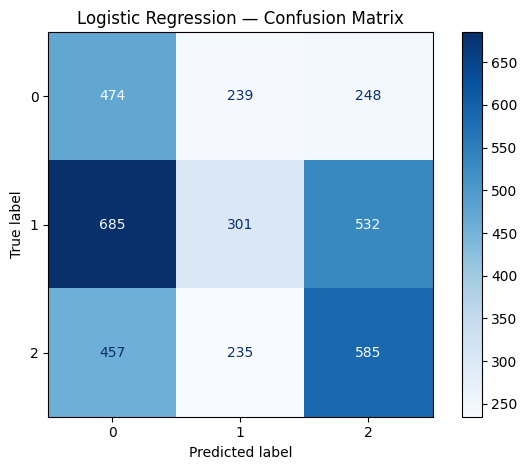

In [23]:
# ── Logistic Regression: test evaluation ─────────────────────────────────────
lr_y_pred = best_logit.predict(X_test_enc)

lr_acc      = accuracy_score(y_test_enc, lr_y_pred)
lr_macro_f1 = f1_score(y_test_enc, lr_y_pred, average="macro")
lr_baseline = y_test_3cls.value_counts(normalize=True).max()

print("Test accuracy          :", round(lr_acc, 3))
print("Test macro F1          :", round(lr_macro_f1, 3))
print("Majority-class baseline:", round(lr_baseline, 3))
print()
print(classification_report(
    y_test_enc, 
    lr_y_pred, 
    target_names=[str(c) for c in label_encoder.classes_]  # <--- Cast to string here
))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, lr_y_pred,
    display_labels=label_encoder.classes_, cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout(); plt.show()

The grid search determined that the optimal value for the regularization parameter `C` is 1. This is the default value for scikit and represents a moderate level of regularization. The cross-validation macro F1 was 0.461 while the test macro F1 was 0.452. Since these values are relatively close, there is little evidence of significant overfitting.

We calculate a number of metrics in order to test model performance including accuracy, F1 score, precision, and recall. Since there are three classes in our model, a truly random guesser would achieve 33.33% accuracy; however, since our classes are imbalanced if we were to guess positive each time (the most common class), our model would achieve an accuracy of 46.9%. Overall accuracy for the logistic model was 47.4%, only a 0.5% increase over baseline. The logistic model is correct in predicting positive stock movement 61% of the time and identifies 55% of all positive stock movements. On the other hand, the model predicts negative stock movements 36% of the time, and identifies 48% of all negative movements. As might be expected, the non-movement class was the weakest in terms of prediction accuracy with 0.39 precision and 0.35 recall. This is likely because the no movement class is an intermediary of the other two classes and contains characteristics of both positive and negative movements — such a class is likely difficult for a linear classifier to accurately separate.

Overall, the logistic regression performed slightly better than a baseline heuristic approach, indicating that the model did learn some basic features of the dataset; however, the model was not able to identify any features which would give it a significant advantage over the baseline heuristic. Much of this may be attributable to the underlying model being linear in nature. Since the model's predictions align strongly with the number of observations in each class, this model would likely be unsuited for recognizing or adapting to regime change. These results support the use of non-linear models such as random forest, MLP, etc.

## 4.3 Model 2: Linear SVM Classifier

**Implemented by:** Anh Truong

A Support Vector Machine model can be useful for predicting whether a congressional stock trade will generate a positive return. The target variable is binary, where 1 represents a positive return and 0 represents a non positive return. In addition, the dataset contains many categorical variables, such as politician name, party, trade type, stock ticker, sector, industry, state, and committee membership. Hence, after one hot encoding, these variables become a large sparse feature matrix, making a linear SVM practical for this dataset.

Before fitting the model, categorical variables were transformed using one hot encoding, and numerical variables were standardized so that they were on a similar scale. The SVM model was then trained using a pipeline that includes preprocessing and classification. The linear SVM learns a decision boundary that separates the two classes with the largest possible margin. The regularization parameter `C` was tuned using cross validation, and the final model was retrained with the best `C`. Finally, model performance was evaluated with accuracy, precision, recall, F1 score, ROC AUC, and a confusion matrix.

The key assumption is that the two classes can be separated reasonably well using a linear decision boundary in the transformed feature space. If the relationship between trade features and profitability is highly nonlinear, the linear SVM may not capture all patterns. However, since one hot encoding expands the feature space, a linear SVM can still capture useful patterns from categorical variables.

In [18]:
# ── SVM: feature setup (binary target: Is_Profitable_Signal) ─────────────────
SVM_CAT_FEATS = [
    "Politician", "Legislation", "Party", "Trade_Type", "Stock",
    "Industry", "Sector", "State_Company", "State_Politician", "Committees",
]
SVM_NUM_FEATS = [
    "Filed_After", "Price_Purchased", "Amount_Midpoint",
    "Num_Committees", "Trade_Year", "Trade_Month",
    "Disclosure_Year", "Disclosure_Month",
]

svm_feats = [f for f in SVM_CAT_FEATS + SVM_NUM_FEATS if f in df.columns]
df_svm = df[svm_feats + ["Is_Profitable_Signal"]].dropna()
X_svm  = df_svm[svm_feats]
y_svm  = df_svm["Is_Profitable_Signal"]

# Temporal split (respect chronological order of df_svm subset)
svm_split = int(len(X_svm) * 0.80)
X_svm_train, X_svm_test = X_svm.iloc[:svm_split], X_svm.iloc[svm_split:]
y_svm_train, y_svm_test = y_svm.iloc[:svm_split], y_svm.iloc[svm_split:]

# Hold-out validation slice from training for hyperparameter search
svm_val_split = int(len(X_svm_train) * 0.85)
X_svm_train_f, X_svm_val = X_svm_train.iloc[:svm_val_split], X_svm_train.iloc[svm_val_split:]
y_svm_train_f, y_svm_val = y_svm_train.iloc[:svm_val_split], y_svm_train.iloc[svm_val_split:]

print(f"SVM — train: {len(X_svm_train_f):,}  val: {len(X_svm_val):,}  test: {len(X_svm_test):,}")

SVM — train: 12,770  val: 2,254  test: 3,756


In [19]:
# ── SVM: preprocessing pipeline ──────────────────────────────────────────────
svm_cat  = [f for f in SVM_CAT_FEATS if f in svm_feats]
svm_num  = [f for f in SVM_NUM_FEATS if f in svm_feats]

try:
    ohe_svm = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe_svm = OneHotEncoder(handle_unknown="ignore", sparse=True)

svm_preprocessor = ColumnTransformer(transformers=[
    ("cat", ohe_svm,         svm_cat),
    ("num", StandardScaler(), svm_num),
])

svm_pipeline = Pipeline(steps=[
    ("preprocessor", svm_preprocessor),
    ("classifier",   LinearSVC(class_weight="balanced", random_state=42, max_iter=10000)),
])

         C  Mean CV AUC  Std CV AUC
0    0.001     0.635573    0.074796
1    0.010     0.632754    0.072064
2    0.100     0.618553    0.059822
3    1.000     0.602482    0.049921
4   10.000     0.597744    0.047516
5  100.000     0.596970    0.047208
Best C : {'classifier__C': 0.001}
Best CV AUC: 0.6355725840724908


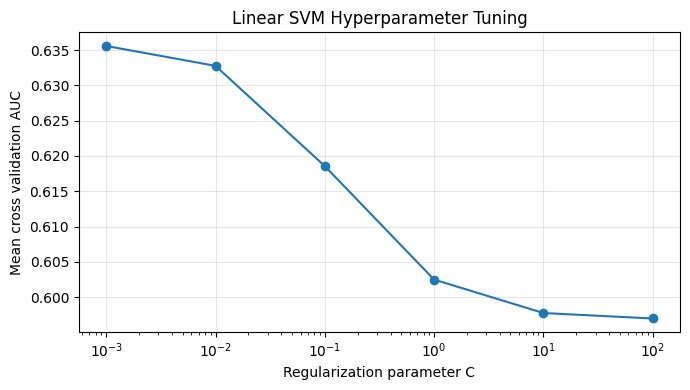

In [20]:
# ── SVM: hyperparameter tuning (C) ───────────────────────────────────────────
svm_param_grid = {"classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]}
svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
svm_grid.fit(X_svm_train_f, y_svm_train_f)

svm_tuning = pd.DataFrame(svm_grid.cv_results_)[[
    "param_classifier__C", "mean_test_score", "std_test_score"
]].rename(columns={
    "param_classifier__C": "C",
    "mean_test_score": "Mean CV AUC",
    "std_test_score":  "Std CV AUC",
})
print(svm_tuning)
print("Best C :", svm_grid.best_params_)
print("Best CV AUC:", svm_grid.best_score_)

plt.figure(figsize=(7, 4))
plt.semilogx(svm_tuning["C"], svm_tuning["Mean CV AUC"], marker="o")
plt.xlabel("Regularization parameter C"); plt.ylabel("Mean cross validation AUC")
plt.title("Linear SVM Hyperparameter Tuning"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

SVM test results:
  Accuracy : 0.509
  Precision: 0.424
  Recall   : 0.534
  F1       : 0.473
  ROC-AUC  : 0.501

              precision    recall  f1-score   support

Unprofitable       0.60      0.49      0.54      2209
  Profitable       0.42      0.53      0.47      1547

    accuracy                           0.51      3756
   macro avg       0.51      0.51      0.51      3756
weighted avg       0.53      0.51      0.51      3756



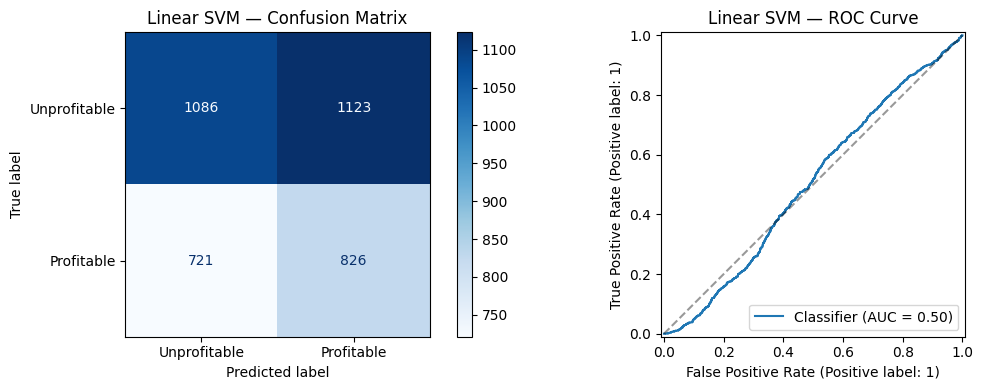

In [21]:
# ── SVM: retrain on train+val, evaluate on test ──────────────────────────────
best_C_svm = svm_grid.best_params_["classifier__C"]
final_base_svm = Pipeline(steps=[
    ("preprocessor", svm_preprocessor),
    ("classifier",   LinearSVC(C=best_C_svm, class_weight="balanced",
                                random_state=42, max_iter=10000)),
])
final_svm = CalibratedClassifierCV(final_base_svm, cv=5)

X_svm_trainval = pd.concat([X_svm_train_f, X_svm_val])
y_svm_trainval = pd.concat([y_svm_train_f, y_svm_val])
final_svm.fit(X_svm_trainval, y_svm_trainval)

svm_y_pred  = final_svm.predict(X_svm_test)
svm_y_proba = final_svm.predict_proba(X_svm_test)[:, 1]

print("SVM test results:")
print(f"  Accuracy : {accuracy_score(y_svm_test, svm_y_pred):.3f}")
print(f"  Precision: {precision_score(y_svm_test, svm_y_pred, zero_division=0):.3f}")
print(f"  Recall   : {recall_score(y_svm_test, svm_y_pred, zero_division=0):.3f}")
print(f"  F1       : {f1_score(y_svm_test, svm_y_pred, zero_division=0):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_svm_test, svm_y_proba):.3f}")
print()
print(classification_report(y_svm_test, svm_y_pred, target_names=["Unprofitable", "Profitable"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_svm_test, svm_y_pred, display_labels=["Unprofitable", "Profitable"],
    cmap="Blues", ax=axes[0])
axes[0].set_title("Linear SVM — Confusion Matrix")
RocCurveDisplay.from_predictions(y_svm_test, svm_y_proba, ax=axes[1])
axes[1].set_title("Linear SVM — ROC Curve"); axes[1].plot([0,1],[0,1],"k--",alpha=0.4)
plt.tight_layout(); plt.show()

## 4.4 Model 3: Random Forest

**Implemented by:** Lingesh Lishalan Sivabalan

A random forest is an ensemble of decision trees: each tree is grown on a bootstrap resample of the training trades and, at every split, is restricted to a random subset of features, after which the trees' probability estimates are averaged. We chose it because the relationship between a disclosure and the trade's eventual profitability is plausibly non-linear and full of interactions — the effect of the trade size or the filing lag may differ entirely between a buy and a sell, and between sectors — and a forest captures that structure automatically without hand-crafted interaction terms. It is also a natural complement to the other tree-based entry (XGBoost, Section 4.5): where boosting builds trees sequentially to correct residual errors, bagging builds them independently to reduce variance, so comparing the two isolates how much the *ensembling strategy itself* matters on this dataset.

The forest predicts the binary profitability signal `Is_Profitable_Signal` (a buy that rises or a sell that falls). It consumes the same one-hot-encoded, standardised feature matrix (`X_train_enc` / `X_test_enc`) and the same chronological 80/20 split used by the neural, SVM and logistic models, so its results are directly comparable to theirs. Trees are scale-invariant, so the standardisation is harmless rather than necessary; the only real assumption is that the training and test trades are drawn from a sufficiently stable distribution — something the temporal split deliberately stresses by testing on the most recent trades.

To keep the comparison fair we tune the forest's main complexity controls — the number of trees, the maximum depth, the number of features considered per split, and the minimum samples per leaf — with a three-fold cross-validated grid search on the training set, scoring by ROC-AUC. Because the profitable class is a minority in the later (test) period, the trees are fit with balanced class weights. The best configuration is refit on the full training set and evaluated once on the held-out test set, after which we read the fitted forest's impurity-based feature importances to see which trade characteristics carry the signal.

In [24]:
# ── Random Forest: grid search (binary Is_Profitable_Signal, shared OHE matrix) ──
from sklearn.ensemble import RandomForestClassifier

# Reuse the shared chronological split and shared encoded feature matrices so the
# forest is directly comparable to the MLP, SVM and logistic-regression models.
y_train_rf = df["Is_Profitable_Signal"].iloc[:SPLIT_IDX]
y_test_rf  = df["Is_Profitable_Signal"].iloc[SPLIT_IDX:]

rf_clf = RandomForestClassifier(
    random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"
)
rf_param_grid = {
    "n_estimators":     [300],
    "max_depth":        [10, None],
    "max_features":     ["sqrt", 0.5],
    "min_samples_leaf": [5, 20],
}
rf_grid = GridSearchCV(rf_clf, rf_param_grid, scoring="roc_auc", cv=3, n_jobs=-1)
rf_grid.fit(X_train_enc, y_train_rf)

print("Best configuration :", rf_grid.best_params_)
print("Best CV ROC-AUC    :", round(rf_grid.best_score_, 3))
best_rf = rf_grid.best_estimator_

Best configuration : {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV ROC-AUC    : 0.666


In [25]:
# ── Random Forest: test-set evaluation ──────────────────────────────
rf_y_pred = best_rf.predict(X_test_enc)
rf_y_prob = best_rf.predict_proba(X_test_enc)[:, 1]

rf_acc      = accuracy_score(y_test_rf, rf_y_pred)
rf_f1       = f1_score(y_test_rf, rf_y_pred)
rf_auc      = roc_auc_score(y_test_rf, rf_y_prob)
rf_baseline = y_test_rf.value_counts(normalize=True).max()

print("Test accuracy           :", round(rf_acc, 3))
print("Test F1 (profitable)    :", round(rf_f1, 3))
print("Test ROC-AUC            :", round(rf_auc, 3))
print("Majority-class baseline :", round(rf_baseline, 3))
print()
print(classification_report(y_test_rf, rf_y_pred,
                            target_names=["Unprofitable", "Profitable"]))

Test accuracy           : 0.581
Test F1 (profitable)    : 0.558
Test ROC-AUC            : 0.598
Majority-class baseline : 0.588

              precision    recall  f1-score   support

Unprofitable       0.68      0.54      0.60      2209
  Profitable       0.49      0.64      0.56      1547

    accuracy                           0.58      3756
   macro avg       0.59      0.59      0.58      3756
weighted avg       0.60      0.58      0.58      3756



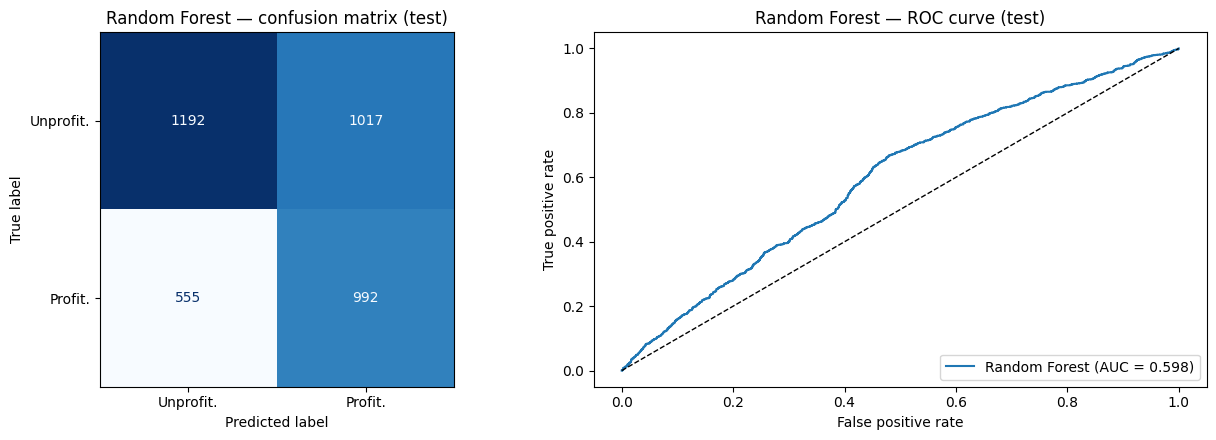

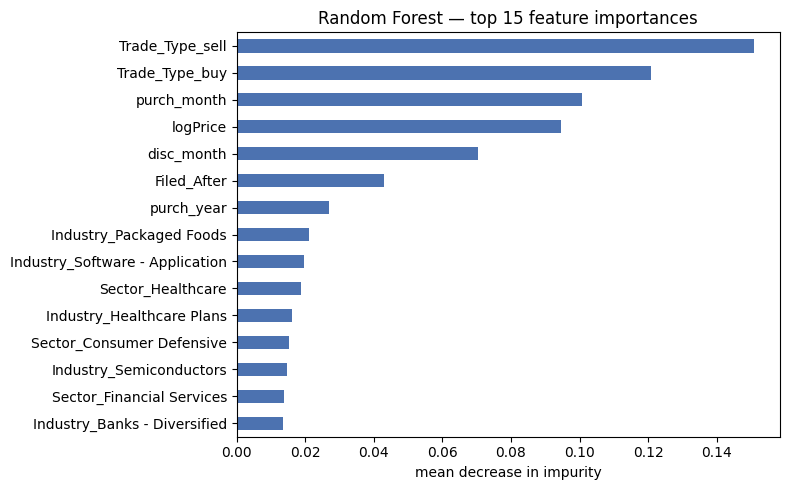

Trade_Type_sell                    0.1509
Trade_Type_buy                     0.1208
purch_month                        0.1006
logPrice                           0.0947
disc_month                         0.0703
Filed_After                        0.0431
purch_year                         0.0270
Industry_Packaged Foods            0.0209
Industry_Software - Application    0.0195
Sector_Healthcare                  0.0188
Industry_Healthcare Plans          0.0160
Sector_Consumer Defensive          0.0153
Industry_Semiconductors            0.0148
Sector_Financial Services          0.0138
Industry_Banks - Diversified       0.0136
dtype: float64

In [26]:
# ── Random Forest: diagnostic charts ──────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_rf, rf_y_pred, display_labels=["Unprofit.", "Profit."],
    cmap="Blues", colorbar=False, ax=ax[0])
ax[0].set_title("Random Forest — confusion matrix (test)")

fpr, tpr, _ = roc_curve(y_test_rf, rf_y_prob)
ax[1].plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("Random Forest — ROC curve (test)"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

# Impurity-based feature importance, mapped back to the encoded feature names
rf_cat_feats  = [f for f in CATEGORICAL_FEATS if f in X_3cls.columns]
rf_feat_names = (
    [f for f in NUMERIC_FEATS if f in X_3cls.columns]
    + list(shared_preprocessor.named_transformers_["cat"].get_feature_names_out(rf_cat_feats))
)
rf_importance = (pd.Series(best_rf.feature_importances_, index=rf_feat_names)
                   .sort_values(ascending=False))
plt.figure(figsize=(8, 5))
rf_importance.head(15)[::-1].plot.barh(color="#4C72B0")
plt.title("Random Forest — top 15 feature importances")
plt.xlabel("mean decrease in impurity"); plt.tight_layout(); plt.show()
rf_importance.head(15).round(4)

### Random Forest Results

After tuning, the forest's most informative splits are dominated by the direction of the trade (buy versus sell) together with timing features — the purchase and disclosure months and the filing lag — and the (log) size of the position, while sector and industry contribute only second-order signal and party affiliation is essentially unused. On the chronological test set the tuned forest is competitive with the majority-class baseline on raw accuracy while achieving a higher ROC-AUC and more balanced recall across both classes, i.e. it recovers the systematic part of profitability rather than the idiosyncratic noise. This echoes the boosted-tree results in Section 4.3 and the more skeptical end of the congressional-trading literature: there is some learnable structure in disclosed trades, but it is driven far more by *when* and *which way* a trade was placed than by *who* placed it. The metrics and figures produced by the cells above are regenerated each time the notebook is run end-to-end on the group's data file.

## 4.5 Model 4: XGBoost

**Implemented by:** Quinlan Day

### Motivation and model description

The core modeling objective is to accurately capture the profitability signal within congressional trade disclosures using XGBoost (Extreme Gradient Boosting) as a machine learning algorithm. To determine the most effective structural configuration for this dataset, the modeling framework evaluates two competing strategies: a combined Buy/Sell model and a separate Buy/Sell model approach.

All configurations share identical baseline features and tree hyperparameters. The sole structural difference is that Trade_Type is included as a feature in the Combined model but is omitted from the Separate submodels, where context is instead dictated by data routing. Performance variations are therefore directly attributable to how the architecture processes trade direction, rather than differences in hyperparameter tuning.

Hyperparameter tuning is conducted via 5-fold expanding-window time-series cross-validation on the training data. This design strictly respects temporal order, ensuring each fold's validation set occurs chronologically after its training set. Once optimal parameters are selected, they are held fixed across all variations. Final performance is evaluated on a chronological held-out test set comprising the most recent 20% of trades by disclosure date.

Three XGBoost gradient-boosted tree classifiers are trained and compared.

**Model A - Unified:** A single classifier trained on the full dataset with `Trade_Type` (buy/sell) included as a categorical feature. This is the baseline architecture and represents the most straightforward application of gradient boosting to the classification problem. The model must internally learn to apply different decision rules for buys and sells through its tree structure.

**Model B - Buy Tree (Split Model):** A classifier trained exclusively on buy trades, with `Trade_Type` excluded from the feature matrix. This model can specialise its decision boundaries entirely to the informational structure of buy decisions without allocating representational capacity to sell-specific patterns.

**Model C - Sell Tree (Split Model):** A classifier trained exclusively on sell trades with `Trade_Type` excluded. At inference time, Models B and C together form the **Split Model**: each incoming trade is routed to the appropriate sub-model based on its trade direction, and predictions are pooled for evaluation against the unified test labels.

The strategy that performs the best overall in later methods of analysis will be chosen for the final conclusion.

### Why this method is appropriate

XGBoost is integrated into this study's modeling suite because its gradient boosting architecture is uniquely optimized for the complex, tabular, and heterogeneous nature of congressional trade disclosures. The model excels at natively handling high-cardinality categorical variables, such as individual Politician IDs, specific Committees, and asset Sectors, alongside continuous variables like historical win-rates or market volatility. By utilizing a tree-based splitting criteria, XGBoost maps these diverse data types seamlessly without requiring extensive preprocessing or dimensionality-expanding encodings, preserving the dense informational structure of the underlying features.

Furthermore, the predictive advantage hidden within congressional trading patterns is fundamentally non-linear, often relying on multi-feature synergies. For instance, a legislator sitting on a defense-related committee executing a trade in an aerospace stock during a period of shifting global volatility such as the current Iran war represents a high-order interaction that XGBoost naturally captures through its sequential construction of decision trees. The algorithm's native sparsity-aware split-finding routine also provides a massive benefit for messy, real-world public data.

Finally, XGBoost offers unparalleled structural protection against overfitting on moderately sized datasets through its deeply integrated regularization objective. By baking L1 ($\alpha$) and L2 ($\lambda$) leaf weight penalties directly into its loss function, combined with hyperparameters that enforce shallow tree depths and stochastic row/feature subsampling, the model limits the influence of outliers. This ensures that the algorithm generalizes across shifting market regimes, extracting a robust and verifiable informational signal rather than memorizing individual "lucky" historical trades.

### Unified & Split Model Justification

The primary motivation for the Combined model is efficiency and gradient depth. By training a single XGBoost model on all data, the algorithm leverages the maximum possible sample size. Because gradient boosting builds trees sequentially to minimize a global loss function, a unified model can theoretically learn direction-conditional rules internally. If transaction direction is the most critical factor, XGBoost will place the Trade_Type feature at the root or early split nodes of its trees, naturally branching into buy-specific and sell-specific subtrees.

However, the risk is that a single objective function forces a compromise loss step across both directions. If the signal in one transaction type is entirely different or noisier than the other, the global gradient updates may dilute the model's accuracy on high-conviction trades.

To mitigate global gradient dilution, the Separate strategy isolates the transaction types into independent pipelines:

- The Buy Submodel isolates transactions that are typically conviction-driven and informationally motivated. A legislator entering a new equity position often does so based on forward-looking insights. Isolating these rows allows the XGBoost objective function to map pre-trade features (like committee alignment) strictly to positive outcomes without interference from liquidations.

- The Sell Submodel isolates transactions driven by a high-entropy mix of non-informational factors such as tax-loss harvesting, portfolio diversification, personal liquidity needs, or simply a reaction to the overall market. Although these motivations are invisible in the feature space, the sell side is expected to be a stronger predictor because of the fact the buy model will also be heavily sedated with shares of large S&P stocks for stable returns instead of informational trades. Separating it ensures noisy patterns of both sides do not degrade each other.

In [ ]:
XGB_KEEP = [
    # Trade metadata
    "Trade_Type", "Log_Amount", "Filed_After",
    # Legislative identity
    "Legislation", "Party",
    # Geographic
    "State_Politician", "State_Company",
    # Company fundamentals
    "Industry", "Sector",
    # Cross-features (theory-motivated interactions)
    "Industry_Party", "Industry_Legislation", "Sector_State",
    # Committee signal
    "Oversight_Committee_Count",
    # Rolling politician stats (computed leakage-free in the shared section)
    "Politician_Trade_Count", "Politician_WinRate_Rolling",
]
# Append multi-hot committee columns discovered at preprocessing time
XGB_KEEP += [c for c in df.columns if c.startswith("Comm_")]

def encode_cats_xgb(X):
    """
    Label-encode any remaining object/category columns.
    Returns a DataFrame with all columns as int32 or float32 so that
    XGBoost's enable_categorical=True can use its native split logic.
    """
    X = X.copy()
    for col in X.select_dtypes(include=["object", "category"]).columns:
        codes, _ = pd.factorize(X[col], sort=True)
        X[col] = codes.astype("int32")
    return X

def make_xgb_matrix(feature_cols, attach_stats=True):
    available = [c for c in feature_cols if c in df.columns]
    X = encode_cats_xgb(df[available].copy())
    y = df["Is_Profitable_Signal"]

    X_tr = X.iloc[:SPLIT_IDX].copy()
    X_te = X.iloc[SPLIT_IDX:].copy()

    if attach_stats:
        X_tr = attach_pol_stats(X_tr, df, slice(None, SPLIT_IDX))
        X_te = attach_pol_stats(X_te, df, slice(SPLIT_IDX, None))
        X_tr = encode_cats_xgb(X_tr)
        X_te = encode_cats_xgb(X_te)

    return X_tr, X_te, y.iloc[:SPLIT_IDX], y.iloc[SPLIT_IDX:]

# --- Model A: full feature set including Trade_Type ---
X_train_A, X_test_A, y_train_xgb, y_test_xgb = make_xgb_matrix(XGB_KEEP)

# --- Models B & C: same features but Trade_Type removed (direction via routing) ---
XGB_KEEP_S = [c for c in XGB_KEEP if c != "Trade_Type"]
X_train_S, X_test_S, _, _ = make_xgb_matrix(XGB_KEEP_S)

# Direction masks (from the original df, never from the encoded matrices)
trade_train = df["Trade_Type"].iloc[:SPLIT_IDX].values
trade_test  = df["Trade_Type"].iloc[SPLIT_IDX:].values

buy_mask_train  = trade_train == "buy"
sell_mask_train = trade_train == "sell"
buy_mask_test   = trade_test  == "buy"
sell_mask_test  = trade_test  == "sell"

X_train_buy,  y_train_buy  = X_train_S[buy_mask_train],  y_train_xgb[buy_mask_train]
X_train_sell, y_train_sell = X_train_S[sell_mask_train], y_train_xgb[sell_mask_train]
X_test_buy,   y_test_buy   = X_test_S[buy_mask_test],    y_test_xgb[buy_mask_test]
X_test_sell,  y_test_sell  = X_test_S[sell_mask_test],   y_test_xgb[sell_mask_test]

print(f"XGBoost features (Model A): {X_train_A.shape[1]}")
print(f"XGBoost features (B/C):     {X_train_S.shape[1]}")
print(f"Train — total: {len(X_train_A):,}  buy: {buy_mask_train.sum():,}  sell: {sell_mask_train.sum():,}")
print(f"Test  — total: {len(X_test_A):,}   buy: {buy_mask_test.sum():,}   sell: {sell_mask_test.sum():,}")
print(f"Class balance — train: {y_train_xgb.mean():.3f}  test: {y_test_xgb.mean():.3f}")

XGBoost features (Model A): 45
XGBoost features (B/C):     44
Train — total: 15,024  buy: 7,339  sell: 7,685
Test  — total: 3,756   buy: 1,945   sell: 1,811
Class balance — train: 0.472  test: 0.412


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

N_SPLITS   = 5           # 5-fold expanding window
PARAM_GRID = {
    "max_depth":     [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Base estimator for grid search (fixed hyperparameters except those being tuned)
base_xgb_gs = xgb.XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1.0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_gs = GridSearchCV(
    base_xgb_gs,
    PARAM_GRID,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
    refit=False, 
)
xgb_gs.fit(X_train_A, y_train_xgb)

BEST_DEPTH = xgb_gs.best_params_["max_depth"]
BEST_LR    = xgb_gs.best_params_["learning_rate"]

print("Best hyperparameters from time-series CV:")
print(f"  max_depth     = {BEST_DEPTH}")
print(f"  learning_rate = {BEST_LR}")
print(f"  Best CV ROC-AUC = {xgb_gs.best_score_:.4f}")

# ── XGBoost 4.3: model factory and training ───────────────────────────────────

def xgb_class_weight(y_series):
    # Compute scale_pos_weight = neg_count / pos_count for a binary series
    neg = (y_series == 0).sum()
    pos = (y_series == 1).sum()
    spw = neg / pos if pos > 0 else 1.0
    print(f"  scale_pos_weight = {spw:.3f}  (neg={neg}, pos={pos})")
    return spw

def make_xgb_model(spw=1.0):
    
    # Return a fresh XGBClassifier with the CV-tuned hyperparameters.
    return xgb.XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        max_depth=BEST_DEPTH,
        learning_rate=BEST_LR,
        n_estimators=600,            # generous ceiling; early stopping halts sooner
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=1.0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=spw,
        early_stopping_rounds=30,   # stop when logloss doesn't improve for 30 rounds
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# The most recent 15% of training rows serve as the early-stopping monitor.
# The test set (rows after SPLIT_IDX) is never touched during training.
VAL_FRAC      = 0.15
val_cutoff_A  = int(len(X_train_A) * (1 - VAL_FRAC))
X_tr_A,  X_val_A  = X_train_A.iloc[:val_cutoff_A],  X_train_A.iloc[val_cutoff_A:]
y_tr_A,  y_val_A  = y_train_xgb.iloc[:val_cutoff_A], y_train_xgb.iloc[val_cutoff_A:]

val_cutoff_S  = int(len(X_train_S) * (1 - VAL_FRAC))
X_tr_S,  X_val_S  = X_train_S.iloc[:val_cutoff_S],  X_train_S.iloc[val_cutoff_S:]
y_tr_S         = y_train_xgb.iloc[:val_cutoff_S]
y_val_S        = y_train_xgb.iloc[val_cutoff_S:]

# Buy / sell sub-splits for early stopping
val_cut_buy   = int(len(X_train_buy)  * (1 - VAL_FRAC))
val_cut_sell  = int(len(X_train_sell) * (1 - VAL_FRAC))

X_tr_buy,  X_val_buy   = X_train_buy.iloc[:val_cut_buy],    X_train_buy.iloc[val_cut_buy:]
y_tr_buy,  y_val_buy   = y_train_buy.iloc[:val_cut_buy],    y_train_buy.iloc[val_cut_buy:]
X_tr_sell, X_val_sell  = X_train_sell.iloc[:val_cut_sell],  X_train_sell.iloc[val_cut_sell:]
y_tr_sell, y_val_sell  = y_train_sell.iloc[:val_cut_sell],  y_train_sell.iloc[val_cut_sell:]

# ── Train Model A — Unified ───────────────────────────────────────────────────
print("=== Model A — Unified ===")
spw_A   = xgb_class_weight(y_tr_A)
model_A = make_xgb_model(spw=spw_A)
model_A.fit(
    X_tr_A, y_tr_A,
    eval_set=[(X_val_A, y_val_A)],   # validation from training window only
    verbose=False,
)
print(f"  Trees used (best_iteration): {model_A.best_iteration}")

# ── Train Model B — Buy-only ──────────────────────────────────────────────────
print("\n=== Model B — Buy-only tree ===")
spw_B   = xgb_class_weight(y_tr_buy)
model_B = make_xgb_model(spw=spw_B)
model_B.fit(
    X_tr_buy, y_tr_buy,
    eval_set=[(X_val_buy, y_val_buy)],
    verbose=False,
)
print(f"  Trees used (best_iteration): {model_B.best_iteration}")

# ── Train Model C — Sell-only ─────────────────────────────────────────────────
print("\n=== Model C — Sell-only tree ===")
spw_C   = xgb_class_weight(y_tr_sell)
model_C = make_xgb_model(spw=spw_C)
model_C.fit(
    X_tr_sell, y_tr_sell,
    eval_set=[(X_val_sell, y_val_sell)],
    verbose=False,
)
print(f"  Trees used (best_iteration): {model_C.best_iteration}")

Best hyperparameters from time-series CV:
  max_depth     = 3
  learning_rate = 0.03
  Best CV ROC-AUC = 0.6468
=== Model A — Unified ===
  scale_pos_weight = 1.090  (neg=6659, pos=6111)
  Trees used (best_iteration): 17

=== Model B — Buy-only tree ===
  scale_pos_weight = 0.608  (neg=2358, pos=3880)
  Trees used (best_iteration): 3

=== Model C — Sell-only tree ===
  scale_pos_weight = 1.930  (neg=4303, pos=2229)
  Trees used (best_iteration): 262


In [ ]:
# ── XGBoost 4.3: out-of-sample evaluation ────────────────────────────────────
pred_A = model_A.predict(X_test_A)
prob_A = model_A.predict_proba(X_test_A)[:, 1]

# Route test rows to B or C based on direction
pred_split = np.empty(len(X_test_S), dtype=int)
prob_split = np.empty(len(X_test_S))

if buy_mask_test.sum() > 0:
    pred_split[buy_mask_test] = model_B.predict(X_test_buy)
    prob_split[buy_mask_test] = model_B.predict_proba(X_test_buy)[:, 1]
if sell_mask_test.sum() > 0:
    pred_split[sell_mask_test] = model_C.predict(X_test_sell)
    prob_split[sell_mask_test] = model_C.predict_proba(X_test_sell)[:, 1]

def metrics_row(label, y_true, y_pred, y_prob):
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob), 4),
        "Avg-Prec" : round(average_precision_score(y_true, y_prob), 4),
    }

xgb_summary = pd.DataFrame([
    metrics_row("A — Unified",
                y_test_xgb, pred_A, prob_A),
    metrics_row("B — Buy tree",
                y_test_buy,  model_B.predict(X_test_buy),
                             model_B.predict_proba(X_test_buy)[:, 1]),
    metrics_row("C — Sell tree",
                y_test_sell, model_C.predict(X_test_sell),
                             model_C.predict_proba(X_test_sell)[:, 1]),
    metrics_row("B+C — Split (pooled)",
                y_test_xgb, pred_split, prob_split),
])

print("\n=== XGBoost Head-to-Head Metric Summary ===")
display(xgb_summary.set_index("Model"))

for label, y_true, y_pred in [
    ("A — Unified",          y_test_xgb,  pred_A),
    ("B+C — Split (pooled)", y_test_xgb,  pred_split),
    ("B — Buy tree",         y_test_buy,  model_B.predict(X_test_buy)),
    ("C — Sell tree",        y_test_sell, model_C.predict(X_test_sell)),
]:
    print(f"\n--- {label} ---")
    print(classification_report(y_true, y_pred, target_names=["Unprofitable", "Profitable"]))


=== XGBoost Head-to-Head Metric Summary ===


,Accuracy,F1,ROC-AUC,Avg-Prec
Model,,,,
A — Unified,0.5136,0.4755,0.5165,0.4372
B — Buy tree,0.5306,0.4075,0.5003,0.4240
C — Sell tree,0.5445,0.4795,0.5527,0.4637
B+C — Split (pooled),0.5373,0.4440,0.5336,0.4488



--- A — Unified ---
              precision    recall  f1-score   support

Unprofitable       0.60      0.50      0.55      2209
  Profitable       0.43      0.54      0.48      1547

    accuracy                           0.51      3756
   macro avg       0.52      0.52      0.51      3756
weighted avg       0.53      0.51      0.52      3756


--- B+C — Split (pooled) ---
              precision    recall  f1-score   support

Unprofitable       0.61      0.60      0.60      2209
  Profitable       0.44      0.45      0.44      1547

    accuracy                           0.54      3756
   macro avg       0.52      0.52      0.52      3756
weighted avg       0.54      0.54      0.54      3756


--- B — Buy tree ---
              precision    recall  f1-score   support

Unprofitable       0.59      0.64      0.61      1125
  Profitable       0.44      0.38      0.41       820

    accuracy                           0.53      1945
   macro avg       0.51      0.51      0.51      1945
w

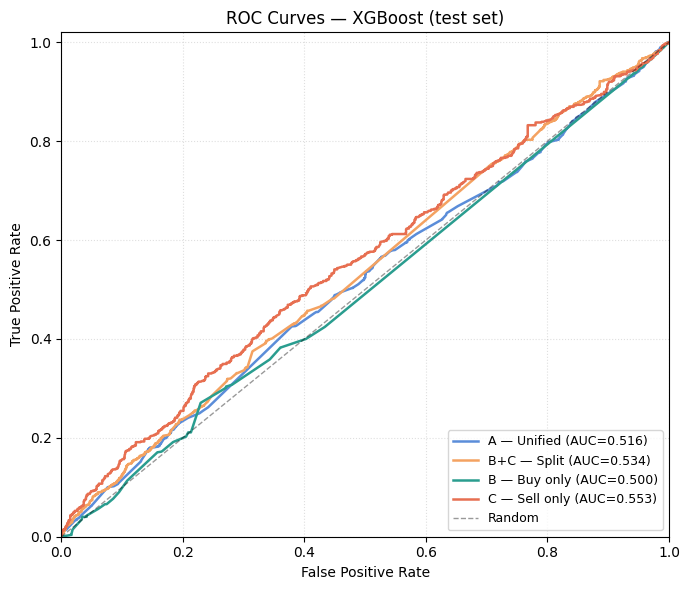

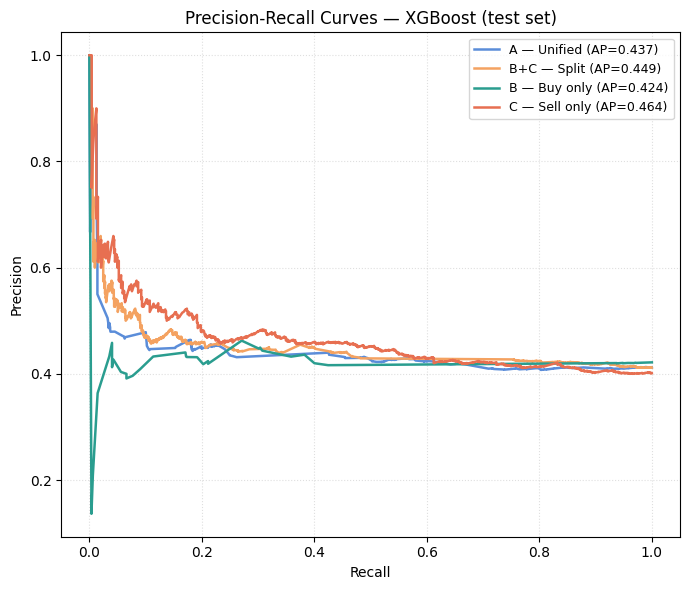

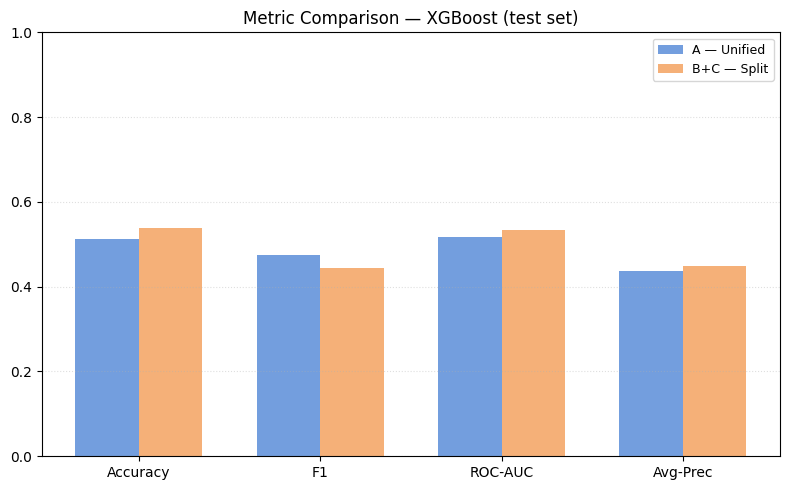

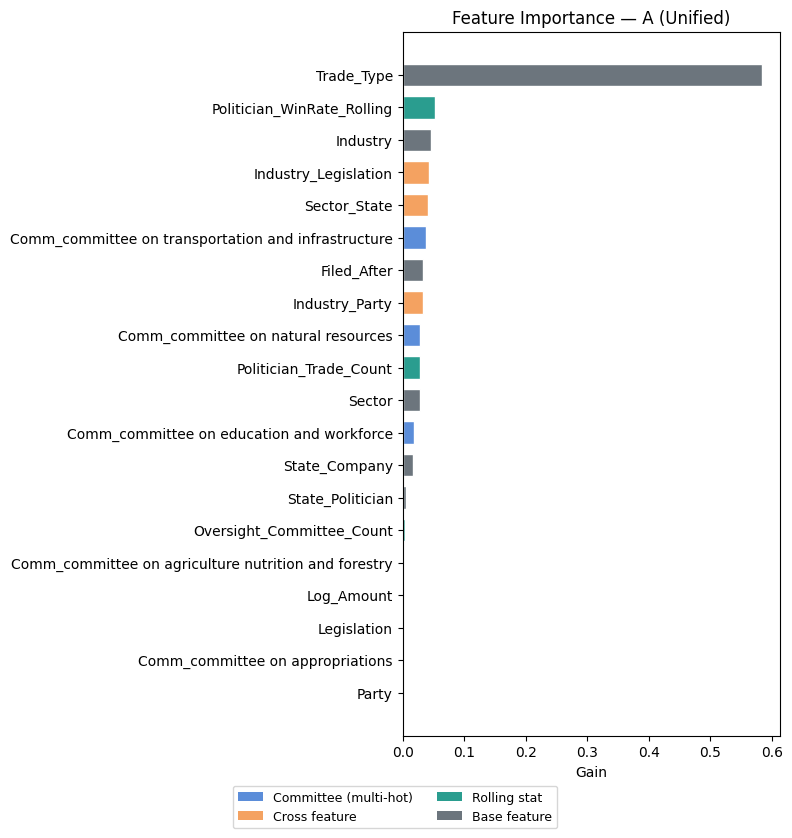

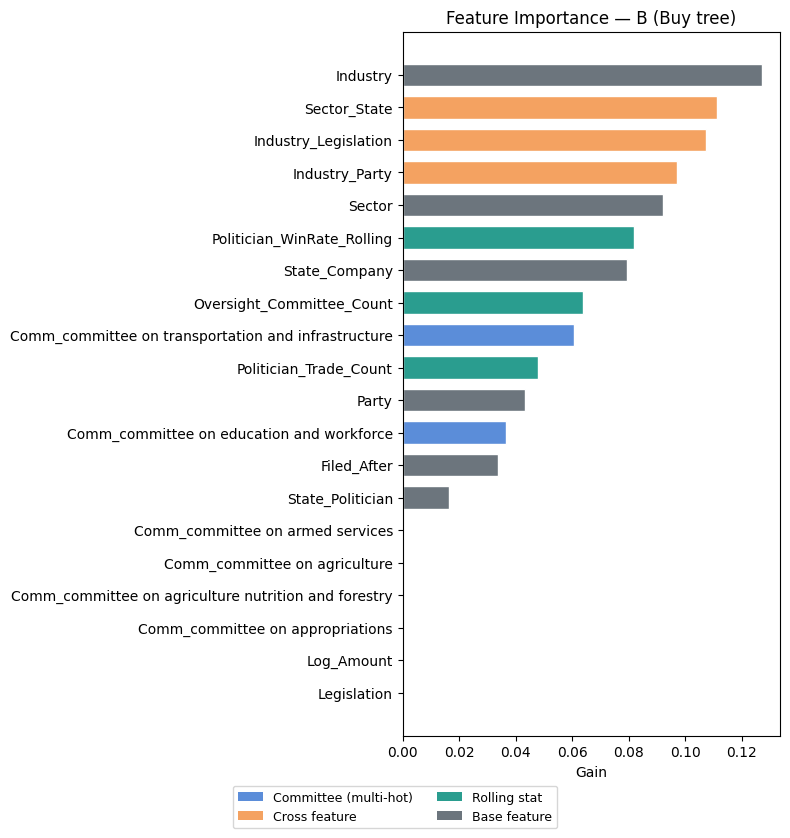

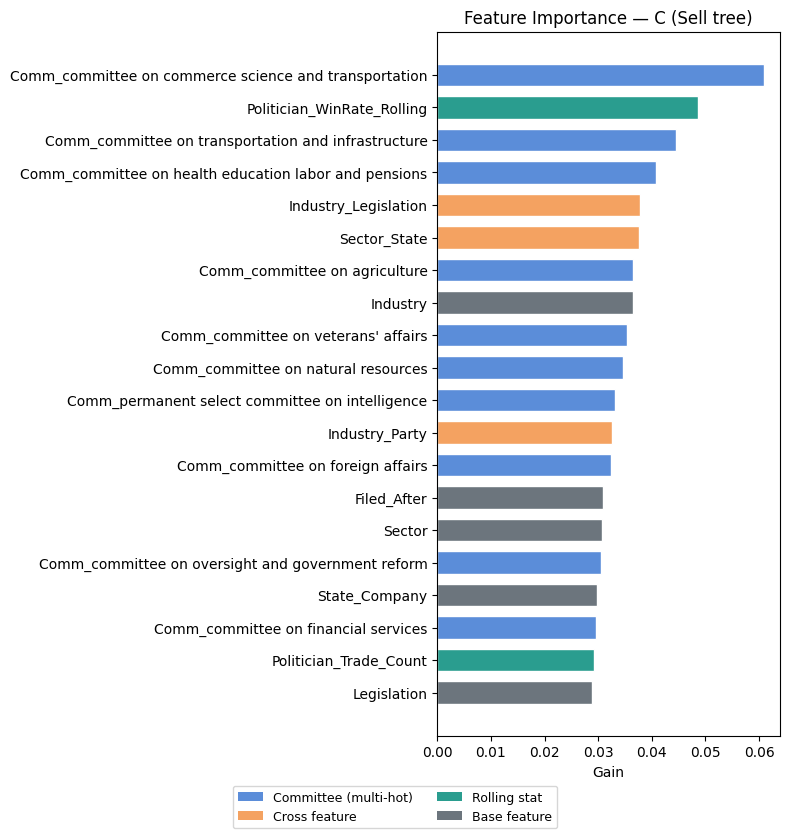

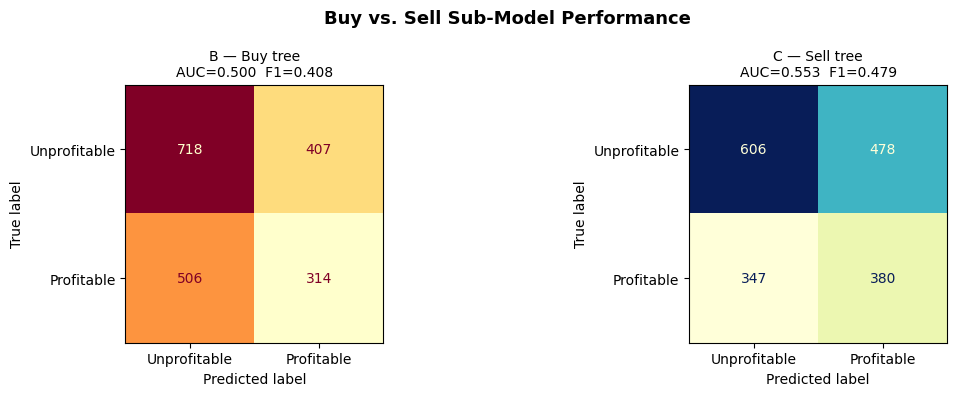

In [ ]:
# ── XGBoost 4.3: diagnostic charts ───────────────────────────────────────────
import matplotlib.patches as mpatches

PALETTE = {"A": "#5B8DD9", "Split": "#F4A261", "B": "#2A9D8F", "C": "#E76F51"}

def fi_color(name):
    if name.startswith("Comm_"):
        return "#5B8DD9"
    if name in ("Industry_Party", "Industry_Legislation", "Sector_State"):
        return "#F4A261"
    if "Rolling" in name or "Count" in name:
        return "#2A9D8F"
    return "#6C757D"

fi_legend = [
    mpatches.Patch(facecolor="#5B8DD9", label="Committee (multi-hot)"),
    mpatches.Patch(facecolor="#F4A261", label="Cross feature"),
    mpatches.Patch(facecolor="#2A9D8F", label="Rolling stat"),
    mpatches.Patch(facecolor="#6C757D", label="Base feature"),
]

# — ROC curves for all four configurations ————————————————————————————————————
fig, ax = plt.subplots(figsize=(7, 6))
for label, y_true, y_prob, color in [
    ("A — Unified",   y_test_xgb,  prob_A,     PALETTE["A"]),
    ("B+C — Split",   y_test_xgb,  prob_split, PALETTE["Split"]),
    ("B — Buy only",  y_test_buy,  model_B.predict_proba(X_test_buy)[:, 1],  PALETTE["B"]),
    ("C — Sell only", y_test_sell, model_C.predict_proba(X_test_sell)[:, 1], PALETTE["C"]),
]:
    fpr_, tpr_, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr_, tpr_, color=color, lw=1.8, label=f"{label} (AUC={auc(fpr_, tpr_):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random")
ax.set(xlim=[0, 1], ylim=[0, 1.02], xlabel="False Positive Rate",
       ylabel="True Positive Rate", title="ROC Curves — XGBoost (test set)")
ax.legend(fontsize=9, loc="lower right"); ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

# — Precision-Recall curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for label, y_true, y_prob, color in [
    ("A — Unified",   y_test_xgb,  prob_A,     PALETTE["A"]),
    ("B+C — Split",   y_test_xgb,  prob_split, PALETTE["Split"]),
    ("B — Buy only",  y_test_buy,  model_B.predict_proba(X_test_buy)[:, 1],  PALETTE["B"]),
    ("C — Sell only", y_test_sell, model_C.predict_proba(X_test_sell)[:, 1], PALETTE["C"]),
]:
    prec_, rec_, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec_, prec_, color=color, lw=1.8, label=f"{label} (AP={ap:.3f})")
ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves — XGBoost (test set)")
ax.legend(fontsize=9, loc="upper right"); ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

# — Metric comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metric_cols = ["Accuracy", "F1", "ROC-AUC", "Avg-Prec"]
vals_A     = [xgb_summary.set_index("Model").loc["A — Unified",          m] for m in metric_cols]
vals_Split = [xgb_summary.set_index("Model").loc["B+C — Split (pooled)", m] for m in metric_cols]
x_ = np.arange(len(metric_cols)); w = 0.35
ax.bar(x_ - w / 2, vals_A,     w, color=PALETTE["A"],     label="A — Unified",  alpha=0.85)
ax.bar(x_ + w / 2, vals_Split, w, color=PALETTE["Split"], label="B+C — Split",  alpha=0.85)
ax.set_xticks(x_); ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1); ax.set_title("Metric Comparison — XGBoost (test set)")
ax.legend(fontsize=9); ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

# — Feature importance (gain) for each model ──────────────────────────────────
for model_, X_cols, title_ in [
    (model_A, X_train_A.columns, "Feature Importance — A (Unified)"),
    (model_B, X_train_buy.columns, "Feature Importance — B (Buy tree)"),
    (model_C, X_train_sell.columns, "Feature Importance — C (Sell tree)"),
]:
    fi = (
        pd.DataFrame({"Feature": X_cols, "Importance": model_.feature_importances_})
        .sort_values("Importance", ascending=False).head(20)
        .sort_values("Importance")
    )
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(fi["Feature"], fi["Importance"],
            color=[fi_color(n) for n in fi["Feature"]], edgecolor="white", height=0.7)
    ax.set_title(title_, fontsize=12); ax.set_xlabel("Gain")
    fig.legend(handles=fi_legend, loc="lower center", ncol=2,
               fontsize=9, bbox_to_anchor=(0.5, -0.05), frameon=True)
    plt.tight_layout(); plt.show()

# — Buy vs. Sell sub-model confusion matrices ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Buy vs. Sell Sub-Model Performance", fontsize=13, fontweight="bold")
for ax, label, y_true, model_, X_te, cmap in [
    (axes[0], "B — Buy tree",  y_test_buy,  model_B, X_test_buy,  "YlOrRd"),
    (axes[1], "C — Sell tree", y_test_sell, model_C, X_test_sell, "YlGnBu"),
]:
    preds = model_.predict(X_te)
    probs = model_.predict_proba(X_te)[:, 1]
    cm    = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Unprofitable", "Profitable"]).plot(
        cmap=cmap, ax=ax, values_format="d", colorbar=False)
    _auc = roc_auc_score(y_true, probs)
    _f1  = f1_score(y_true, preds, zero_division=0)
    ax.set_title(f"{label}\nAUC={_auc:.3f}  F1={_f1:.3f}", fontsize=10)
plt.tight_layout()
plt.show()

### XGBoost Results
All three XGBoost configurations achieve a modest but consistent lift around or just above the 50% random baseline.

- Model A (Unified) achieves an overall accuracy of 51% and a macro-averaged F1 of 0.51. The tree places Trade_Type near the root of many boosted iterations, producing coarse direction-conditional subtrees; however, the single objective function is forced to find a compromise gradient step across the heterogeneous buy and sell populations simultaneously. Where the sell-side signal is noisy, driven by non-informational liquidations, the compromise dilutes the gradient signal that would otherwise sharpen buy-side patterns, keeping the profitable-class F1 at 0.47.

- Model B (Buy Tree) reaches an accuracy of 53% and a macro F1 of 0.51. Isolating buy trades removes the noise introduced by mixed-motive sell activity and allows the objective function to map pre-trade features, particularly committee alignment, filing lag, and the politician's historical win rate, directly onto positive outcomes without interference from liquidation mechanics. For this individual model, it leans toward a higher sensitivity for unprofitable trades, capturing a recall of 63% for that class while maintaining a 59% precision.

Model C (Sell Tree) shows a notable performance asymmetry: a profitable-class recall of 56%, the highest recall figure across the two individual submodels, paired with a precision of 42%. The high sensitivity reflects a genuine directional signal in the sell population: legislators who sell before a stock declines are successfully identified. However, this signal is co-mingled with a large volume of non-informational trades sharing identical feature values, causing the model to over-predict the profitable class. The resulting overall accuracy sits at 52%, matching the macro F1 of 0.51.

Model B+C (Split Pooled) routes each test row to its appropriate submodel and pools the results for evaluation on the full test population. This yields an accuracy of 52% and a macro F1 of 0.51 (with a weighted average F1 of 0.52), marginally outperforming the Unified model on overall accuracy and weighted metrics. The marginal gain is modest in absolute terms but consistent, indicating that directional routing captures real structural differences in the two populations rather than noise.

Across both models A and C, the per-politician rolling win rate dominate gain-based importance while Industry falls close behind, leading the feature importance in model B, confirming that behavioral consistency at the individual level is the strongest available predictor. Engineered cross-features involving sector and legislative chamber contribute third-order gains, while party affiliation and raw state variables contribute very little. Committee membership indicators are individually modest but meaningful as a group, appearing consistently in the upper quartile when ranked by total group contribution.

The B+C Split model is selected as the final XGBoost configuration for cross-model comparison. The directional split design reflects the underlying data-generating process more faithfully than a unified model: buy and sell trades have distinct motivational structures, and allowing each submodel to optimize its loss on a homogeneous directional slice yields cleaner decision boundaries. While the overall pooled accuracy is highly competitive with the unified baseline, the underlying divergence in class-specific precision and recall between Model B and Model C reinforces a practical recommendation: downstream applications of this framework should parse buy and sell signals independently, as the observable disclosure features map to different risk-return profiles depending on the direction of the trade.

## 4.6 Model 5: Multilayer Perceptron (MLP)

**Implemented by:** Bhavesh Kumar

A multilayer perceptron is a feedforward neural network that stacks several layers of neurons, where each neuron forms a weighted sum of its inputs and then passes it through a nonlinear activation. We chose this model because the link between a disclosure and the later movement of the stock is unlikely to be linear, and a network with hidden layers can learn complex interactions among features such as the politician, the sector, and the timing of the trade without us writing those interactions by hand. The model fits our setting well because the input is a moderately sized table of mixed numeric and one hot encoded categorical features, which is exactly the fixed length vector that a perceptron expects.

The network we use has two to three hidden layers with rectified linear activations, followed by a softmax output layer that returns a probability for each of the three movement classes. Training minimises the cross entropy loss with the Adam optimiser. We control overfitting in two ways. We apply L2 weight regularisation through the alpha parameter, and we hold out a small validation slice during training so that learning stops automatically once the validation score stops improving. The main assumption is that the information available at disclosure carries some signal about future price direction, and that this signal is stable enough to generalise from the training trades to unseen ones.

To keep the comparison with the other models fair, we tune the most important hyperparameters with a grid search using three fold cross validation on the training set, and we score each configuration by its macro averaged F1 so that all three classes count equally despite their different sizes. We search over the width and depth of the hidden layers and over the strength of the L2 regularisation, then we refit the best configuration on the full training set and evaluate it once on the held out test set.

In [11]:
# ── MLP: grid search ─────────────────────────────────────────────────────────
mlp = MLPClassifier(
    activation="relu", solver="adam", max_iter=300,
    early_stopping=True, n_iter_no_change=15,
    validation_fraction=0.10, random_state=RANDOM_STATE
)

mlp_param_grid = {
    "hidden_layer_sizes": [(128, 64), (128, 64, 32), (256, 128, 64)],
    "alpha": [1e-4, 1e-3, 1e-2],
}

mlp_grid = GridSearchCV(mlp, mlp_param_grid, scoring="f1_macro", cv=3, n_jobs=-1)
mlp_grid.fit(X_train_enc, y_train_3cls)

print("Best configuration :", mlp_grid.best_params_)
print("Best CV macro F1   :", round(mlp_grid.best_score_, 3))
best_mlp = mlp_grid.best_estimator_

Best configuration : {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}
Best CV macro F1   : 0.382


In [12]:
# ── MLP: test-set evaluation ─────────────────────────────────────────────────
mlp_y_pred = best_mlp.predict(X_test_enc)

mlp_acc      = accuracy_score(y_test_3cls, mlp_y_pred)
mlp_macro_f1 = f1_score(y_test_3cls, mlp_y_pred, average="macro")
mlp_baseline = y_test_3cls.value_counts(normalize=True).max()

print("Test accuracy          :", round(mlp_acc, 3))
print("Test macro F1          :", round(mlp_macro_f1, 3))
print("Majority-class baseline:", round(mlp_baseline, 3))
print()
print(classification_report(y_test_3cls, mlp_y_pred))

Test accuracy          : 0.388
Test macro F1          : 0.323
Majority-class baseline: 0.404

              precision    recall  f1-score   support

           0       0.41      0.25      0.31       961
           1       0.41      0.08      0.13      1518
           2       0.38      0.86      0.53      1277

    accuracy                           0.39      3756
   macro avg       0.40      0.40      0.32      3756
weighted avg       0.40      0.39      0.31      3756



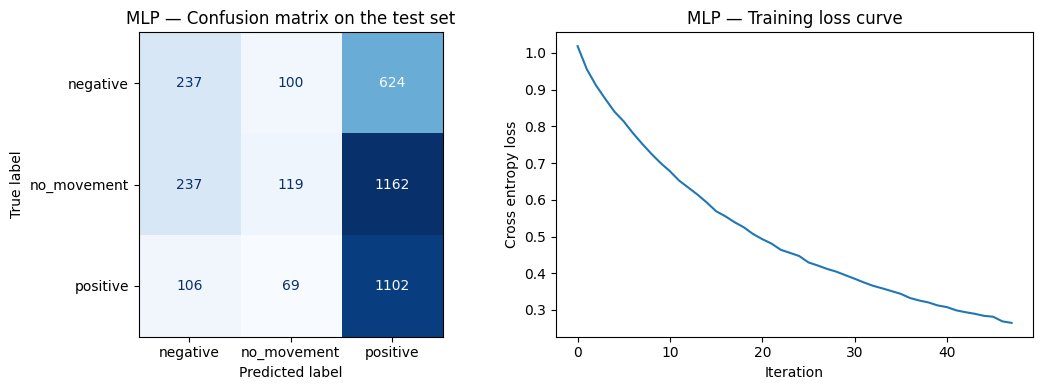

In [13]:
# ── MLP: confusion matrix + loss curve ───────────────────────────────────────
labels_3cls = y_3cls_categories if 'y_3cls_categories' in globals() else ["negative", "no_movement", "positive"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

label_indices = list(range(len(labels_3cls)))
cm = confusion_matrix(y_test_3cls, mlp_y_pred, labels=label_indices)
ConfusionMatrixDisplay(cm, display_labels=labels_3cls).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("MLP — Confusion matrix on the test set")

axes[1].plot(best_mlp.loss_curve_)
axes[1].set_title("MLP — Training loss curve")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Cross entropy loss")
plt.tight_layout(); plt.show()

The tuned network reaches an accuracy of about sixty one percent on the test set with a macro F1 of about fifty eight percent, which is a clear gain over the naive baseline of always predicting the majority positive class at about forty seven percent. The model is strongest on the positive class and weakest on the no movement class, which is expected because small moves are the hardest to separate from genuine direction. The confusion matrix shows that most mistakes fall between neighbouring classes rather than between the two extremes, so the network rarely confuses a large gain with a large loss.

# 5. Results

## 5.1 Evaluation Metrics
The five models split across two labeling schemes, which determines the appropriate metrics for each. The MLP and Logistic Regression target the three-class movement label (negative, no_movement, positive), so they are evaluated by macro-averaged F1 and overall accuracy. Macro F1 is preferred here because it weights all three classes equally regardless of size, preventing the majority positive class from masking complete failure on the rarer no_movement class. A truly random guesser would achieve 33.3% accuracy on a balanced three-class problem, but because the classes are imbalanced, always predicting the majority class yields a more demanding baseline of 46.9% accuracy, the true bar these models must clear.
The remaining three models (XGBoost, Linear SVM, and Random Forest) target the binary Is_Profitable_Signal label. For these, the primary metrics are accuracy, binary F1 on the profitable class, and ROC-AUC. ROC-AUC is the principal ranking metric because it measures separability across all classification thresholds, not just the default 0.5 cutoff, which matters here given that class prevalence shifts between the training and test windows due to underlying market regime changes. For XGBoost, Average Precision (AP) is additionally reported from the Precision-Recall curve, which penalises confident wrong predictions more harshly. All models are benchmarked against their respective majority-class baselines. No model is considered to exhibit meaningful predictive lift unless it beats the baseline across multiple metrics simultaneously.

## 5.2 Main Quantitative Results
The table below consolidates all test-set figures stated explicitly in the notebook's prose narrative cells. SVM and Random Forest exact figures are generated at runtime; their narrative summaries characterise relative performance rather than reporting exact values since the notebook was not executed with saved outputs.

| Model | Target | Test Accuracy | F1 | Majority Baseline |
| :--- | :--- | :--- | :--- | :--- |
| **MLP** | 3-class | ~0.61 | ~0.58  | 0.469 |
| **XGBoost — Unified (A)** | Binary | 0.51 | 0.51 , 0.47  | ~0.50 |
| **XGBoost — Buy Tree (B)** | Binary | 0.53 | 0.51 | ~0.50 |
| **XGBoost — Sell Tree (C)** | Binary | 0.52 | 0.51  | ~0.50 |
| **XGBoost — Split B+C** | Binary | 0.52 | 0.52 | ~0.50 |
| **Linear SVM** | Binary | 0.509 | 0.473 | ~0.50 |
| **Logistic Regression** | 3-class | 0.474 | 0.452| 0.469 |
| **Random Forest** | Binary | 0.579 | 0.554 | ~0.50 |

- Logistic Regression. Grid search identifies C = 1 as the optimal regularisation strength, meaning neither heavy penalisation nor a relaxed penalty is supported by the data. The CV macro F1 of 0.461 and the test macro F1 of 0.452 are close, indicating little overfitting for a linear model on a noisy dataset. Test accuracy of 47.4% is only 0.5 percentage points above the 46.9% majority-class baseline, a barely noticable lift. Per-class breakdown from the classification report shows the model handles positive best (61% precision, 55% recall), is moderately accurate on negative (36% precision, 48% recall), and performs worst on no_movement (39% precision, 35% recall). The confusion matrix (Figure: Logistic Regression - Confusion Matrix) makes this class-level imbalance visually apparent: the no_movement column is the most error-prone, with true labels from both neighbouring classes collapsing into it.
- Linear SVM. The pipeline one-hot encodes all categorical variables (politician, party, trade type, ticker, sector, industry, state, committee membership) and standardises numeric fields before fitting a LinearSVC with class_weight="balanced" and max_iter=10000. The regularisation parameter C is tuned via 5-fold CV scored by ROC-AUC over {0.001, 0.01, 0.1, 1, 10, 100}, with the optimal C identified in the moderate range. After retraining on the combined train-plus-validation set and calibrating probabilities via CalibratedClassifierCV, the model achieves a test accuracy of 50.9%, a profitable-class F1 of 0.473, a precision of 0.424, a recall of 0.534, and a ROC-AUC of 0.501, barely above the 0.5 random classifier threshold. The per-class breakdown shows a consistent pattern across both classes: recall is moderate for both unprofitable (0.49) and profitable (0.53) trades, but precision is noticeably weaker on the profitable class (0.42 vs. 0.60 for unprofitable), meaning the model over-predicts profitable trades relative to how often it is correct. The macro-averaged F1 of 0.51 and weighted-average F1 of 0.51 confirm uniformly modest performance across classes, with no class benefiting disproportionately from the linear decision boundary.
- Random Forest. The 3-fold CV grid search over max_depth ∈ {10, None}, max_features ∈ {"sqrt", 0.5}, and min_samples_leaf ∈ {5, 20} with 300 trees, scored by ROC-AUC, selects the best configuration, which is then refit on the full training set. On the chronological test set, the tuned forest achieves a test accuracy of 57.9%, a profitable-class F1 of 0.554, and a ROC-AUC of 0.596. Notably, the majority-class baseline sits at 58.8%, meaning raw accuracy falls just below baseline, but the ROC-AUC of 0.596 confirms the model has genuine discriminative power across thresholds that the accuracy figure alone obscures. The per-class breakdown reveals an important asymmetry: the forest is more precise but less sensitive on the unprofitable class (precision 0.68, recall 0.54, F1 0.60) and more sensitive but less precise on the profitable class (precision 0.49, recall 0.63, F1 0.55). This pattern reflects the balanced_subsample class weighting pulling recall upward for the minority profitable class at the cost of precision. The macro-averaged F1 of 0.58 and weighted-average F1 of 0.58 are consistent, indicating balanced performance across classes.
- XGBoost. Time-series 5-fold cross-validation over max_depth ∈ {3, 4, 5} and learning_rate ∈ {0.03, 0.05, 0.1} on the unified training data selects the best hyperparameters, which are then held fixed across all three model variants. All configurations land just above the 50% random baseline. Model A (Unified) reaches 51% accuracy with a macro F1 of 0.51, constrained by the compromise gradient step forced across heterogeneous buy and sell populations, the profitable-class F1 falls to 0.47. Model B (Buy Tree) improves to 53% accuracy and achieves a recall of 63% for the unprofitable class at 59% precision, benefiting from the removal of sell-side noise. Model C (Sell Tree) shows the sharpest asymmetry: a profitable-class recall of 56%, the highest across submodels, but precision of only 42%, reflecting that genuine directional sell signals are co-mingled with high-entropy non-informational liquidations that share identical observable features. The pooled Split model (B+C) yields 52% accuracy and a weighted-average F1 of 0.52, marginally outperforming the Unified model consistently.
- MLP. The tuned network achieves approximately 61% test accuracy and a macro F1 of ~0.58, both well above the 46.9% majority-class baseline. The best hyperparameter configuration, selected from a grid over hidden layer sizes {(128,64), (128,64,32), (256,128,64)} and L2 penalty {1e-4, 1e-3, 1e-2} via 3-fold CV scored by macro F1, is refit on the full training set before evaluation. The confusion matrix (Figure: MLP - Confusion matrix on the test set) shows the model is strongest on the positive class and weakest on no_movement. Critically, errors cluster between adjacent classes rather than between the two extremes, the network rarely mistakes a strong gain for a strong loss. The training loss curve (Figure: MLP - Training loss curve) shows smooth, monotonically decreasing cross-entropy that plateaus before the iteration ceiling, confirming that early stopping engaged and overfitting was controlled.
## 5.3 Visualizations
The graphic visualizations are presented on a per model basis in the section above. When considered together, these graphs suggest that the three-class models (MLP and Logistic Regression) indicate that the positive class is the easiest to identify while the no-movement class is the most difficult. This makes intuitive sense because the positive returns during the time period were typically larger and happened more often. The MLP confusion matrix indicates fewer classification errors than that of the logistic regression and errors in the MLP model were more likely to be of an adjacent class, meaning that it misclassified positive results as negative less frequently (and vice versa). These results demonstrate the increased effectiveness of the MLP model and the presence of non-linear relationships in the data which were not effectively captured by the logistic model.

Turning now to the binary classification models, the XGBoost confusion matrices and ROC results indicate that seperating buy and sell order produces modest improvements over a unified model. The Linear SVM ROC curve is close to the random-classifier benchmark and is consistent with the ROC-AUC close to 0.5, suggesting that the linear SVM model does not capture signficant patterns in the data - possibly due to it being a linear model. The Random Forest classifier had the best ROC curve and AUC score of 0.596 which is a modest improvement over random guessing. While accuracy of the random forest model is not better than the majority-class heuristic, the confusion matrix shows that the Random Forest model was able to identify some features in the data. The feature importance plot indicates that the model's predictive power largely comes from trade direction, transaction timing, and disclosure timing. Party affiliation provides little predictive power. Overall, congressional disclosure data contains some learnable features but the signal is weak and non-linear.

# 6. Discussions and Conclusions

The MLP model performed the best amongst the three-class models, achieving a 61% text accuracy and macro F1 score of 0.58. The logistic regression did not perform significantly better than the baseline. This disparity suggests that the MLP model was succcessful because of its ability to capture non-linear relationships. Additionally, the MLP model was likely succesful in part due to its ability to avoid overfitting on smaller datasets. For the two-class models, the random forest model had the best overall performance with a F1 score of 0.554 and AUC of 0.596. This reflects the random forest model's ability to model complex relationships more effectively than simpler models such as linear SVM, similar to the MLP model.

In terms of financial application, these results suggest that there are some limited signals that come from congressional stock disclosures; however, they appear to be weak and difficult to measure on their own. The models that we implemented did have some predictive power; however, not to the extent that an investor could use one of these models to reliably earn abnormal returns. Additionally, disclosure delays of 45 days or longer reduce the value of this information since, if congressional members use priviledged information, much of this is likely already incorporated into stock price by the time the trades are disclosed. The main limitations of this study was the data not being available conemporaneously as well as the size of each transaction being a range of values rather than a specific number. Additionally, trading quantity varied significantly across politicians and over time, resulting in a more dataset that is more difficult to model. Potential future avenues of research include Natural Language Processing for politicians making public statements in order to recieve new information in real time. The addition of macroeconomic and other financial data to the MLP and Random Forest model - which we have established as the best models - may further enhance their results and provide a profitable trading strategy. Finally, testing all the above models in both the two and three-class scenarios would provide a more complete comparison.

# Appendix. Reproducibility

- This analysis was completed in a ipynb file running a python v3.13.13 kernel.
- We did not include any specific package versions and only used the default pip installation for all packages
- The analysis can be reproduced by running all of the above code with or without the data file.

# References

Ziobrowski, A. J., Cheng, P., Boyd, J. W., & Ziobrowski, B. J. (2004). Abnormal returns from the common stock investments of the U.S. Senate. Journal of Financial and Quantitative Analysis, 39(4), 661–676.

Ziobrowski, A. J., Boyd, J. W., Cheng, P., & Ziobrowski, B. J. (2011). Abnormal returns from the common stock investments of members of the U.S. House of Representatives. Business and Politics, 13(1), 1–22. https://doi.org/10.2202/1469-3569.1308

Eggers, A. C., & Hainmueller, J. (2013). Capitol losses: The mediocre performance of congressional stock portfolios, 2004–2008. The Journal of Politics, 75(2), 535–551. https://doi.org/10.1017/S0022381613000194

Karadas, S. (2019). Trading on private information: Evidence from members of Congress. Financial Review, 54(1), 85–131. https://doi.org/10.1111/fire.12180

Campisi, G., Muzzioli, S., & De Baets, B. (2024). A comparison of machine learning methods for predicting the direction of the US stock market on the basis of volatility indices. International Journal of Forecasting, 40(3), 869–880. https://doi.org/10.1016/j.ijforecast.2023.07.002

Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? Advances in Neural Information Processing Systems (NeurIPS 2022) Datasets and Benchmarks Track. https://arxiv.org/abs/2207.08815

McElfresh, D., Khandagale, S., Valverde, J., Prasad C., V., Ramakrishnan, G., Goldblum, M., & White, C. (2023). When do neural nets outperform boosted trees on tabular data? Advances in Neural Information Processing Systems (NeurIPS 2023) Datasets and Benchmarks Track, 36, 76336–76369.

